In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
            
#Load dataset
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

df = hf_df.copy()

## **Q1.Which cci_score groups should be prioritized when designing a follow-up program**
##### ***Reasoning:This grouping and analysis helps to identify Which group of patients should receive more intensive follow-up based on risk***

In [2]:

# -----------------------------
# 1. Clean variables
# -----------------------------
df["cci_score"] = pd.to_numeric(df["cci_score"], errors="coerce")

# Short-term adverse outcomes
for col in ["readmission_28d", "mortality_28d", "readmission_3mo", "death_3mo"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["poor_outcome"] = df[["readmission_28d", "mortality_28d", "readmission_3mo", "death_3mo"]].max(axis=1)

# -----------------------------
# 2. Create CCI groups
# -----------------------------
df["cci_group"] = pd.cut(
    df["cci_score"],
    bins=[-1, 1, 3, 5, 10, 20],
    labels=["0-1", "2-3", "4-5", "6-10", "11+"],
    right=True
)

# -----------------------------
# 3. Summarize risk by CCI group
# -----------------------------
outcome_cols = ["readmission_28d", "mortality_28d", "readmission_3mo", "death_3mo", "poor_outcome"]

cci_summary = (
    df.groupby("cci_group")[outcome_cols]
      .mean()
      .mul(100)
      .round(2)
)

print("Outcome rates by CCI group (%)")
print(cci_summary)

# -----------------------------
# 4. Identify high-priority groups
# -----------------------------
priority_groups = cci_summary.sort_values("poor_outcome", ascending=False).reset_index()

# Define a practical follow-up priority threshold
high_priority = priority_groups[priority_groups["poor_outcome"] >= priority_groups["poor_outcome"].median()].copy()
print("\nHigh-priority CCI groups for follow-up program:")
print(high_priority)



Outcome rates by CCI group (%)
           readmission_28d  mortality_28d  readmission_3mo  death_3mo  \
cci_group                                                               
0-1                   6.42           1.45            22.40       1.57   
2-3                   6.84           1.78            24.74       2.06   
4-5                  11.93           5.50            42.20       6.42   
6-10                  0.00           0.00           100.00       0.00   
11+                    NaN            NaN              NaN        NaN   

           poor_outcome  
cci_group                
0-1               23.97  
2-3               26.80  
4-5               48.62  
6-10             100.00  
11+                 NaN  

High-priority CCI groups for follow-up program:
  cci_group  readmission_28d  mortality_28d  readmission_3mo  death_3mo  \
0      6-10             0.00            0.0            100.0       0.00   
1       4-5            11.93            5.5             42.2       6.42   



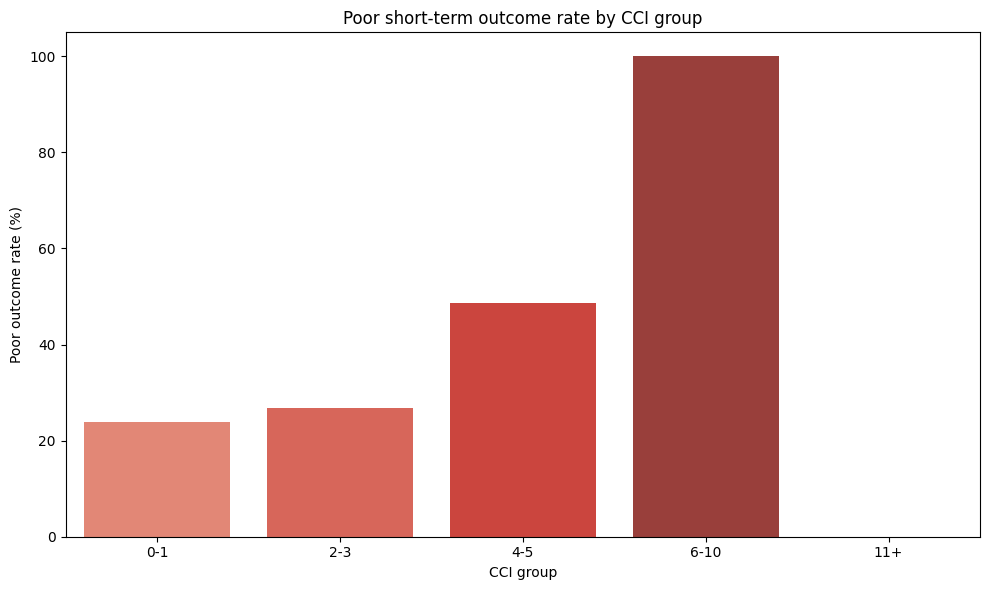


Patient counts by CCI group:
  cci_group  n_patients
0       0-1         826
1       2-3        1067
2       4-5         109
3      6-10           1
4       11+           0


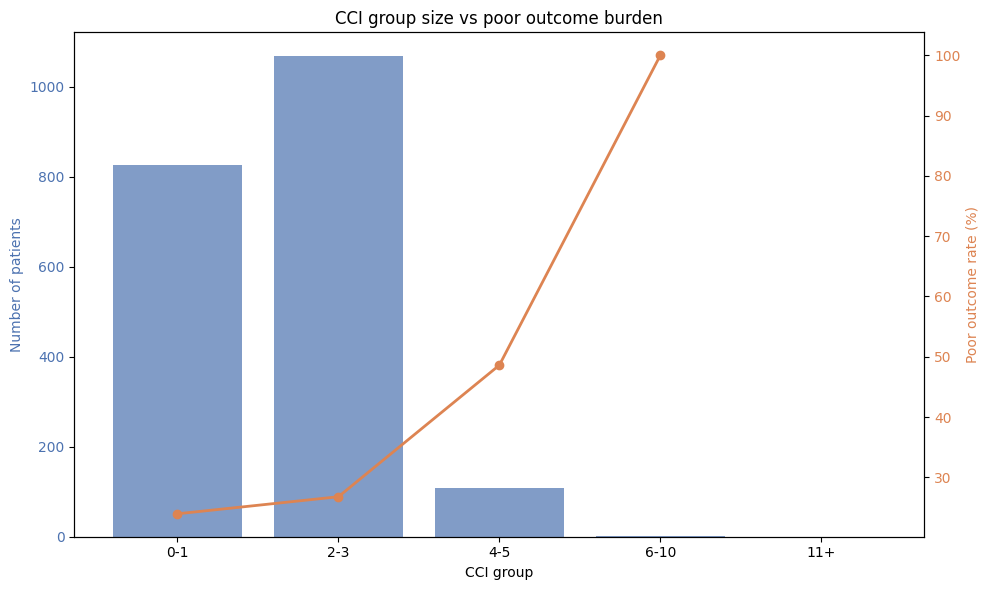

In [3]:
# -----------------------------
# 5. Plot: outcome rates by CCI group
# -----------------------------
plot_df = cci_summary.reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="cci_group", y="poor_outcome", palette="Reds_d")
plt.title("Poor short-term outcome rate by CCI group")
plt.xlabel("CCI group")
plt.ylabel("Poor outcome rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Optional: count patients in each CCI group
# -----------------------------
count_df = df["cci_group"].value_counts().sort_index().reset_index()
count_df.columns = ["cci_group", "n_patients"]

print("\nPatient counts by CCI group:")
print(count_df)

# Combined plot: counts + poor outcome rate
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "#4C72B0"
color2 = "#DD8452"

ax1.bar(count_df["cci_group"], count_df["n_patients"], color=color1, alpha=0.7, label="Patients")
ax1.set_xlabel("CCI group")
ax1.set_ylabel("Number of patients", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(plot_df["cci_group"], plot_df["poor_outcome"], color=color2, marker="o", linewidth=2, label="Poor outcome %")
ax2.set_ylabel("Poor outcome rate (%)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("CCI group size vs poor outcome burden")
plt.tight_layout()
plt.show()

## ***Q2.Do patients with recorded chronic kidney disease have higher readmission rates, suggesting a need to review their follow-up coordination?***
##### *Reasoning:This analysis helps guide care coordination decisions if patients with CKD require more intensive follow-up support to prevent early readmission.*

           Outcome  No CKD (%)  CKD (%)  Difference (%)
0  readmission_28d        6.19     9.49            3.30
1  readmission_3mo       23.01    30.59            7.58
2  readmission_6mo       36.11    46.20           10.09
3     poor_outcome       36.25    46.41           10.17


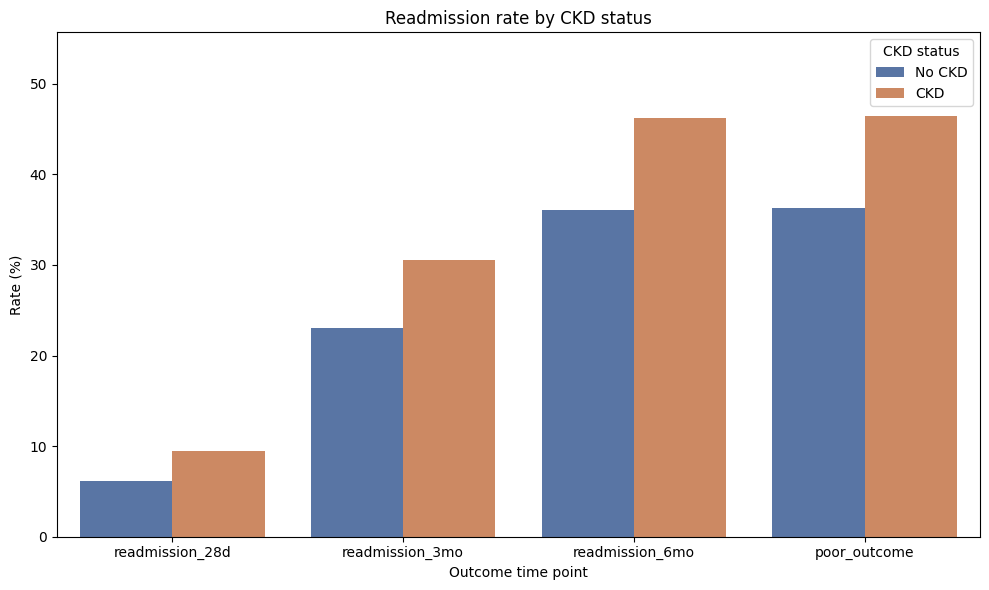


CKD counts:
ckd
No CKD    1534
CKD        474
Name: count, dtype: int64


In [4]:
# -----------------------------
# 1. Prepare variables
# -----------------------------
# CKD indicator: mod_severe_ckd
df["ckd"] = pd.to_numeric(df["mod_severe_ckd"], errors="coerce").fillna(0)

# Readmission outcomes
for col in ["readmission_28d", "readmission_3mo", "readmission_6mo"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Short-term poor outcome indicator
df["poor_outcome"] = df[["readmission_28d", "readmission_3mo", "readmission_6mo"]].max(axis=1)

# -----------------------------
# 2. Compare readmission rates by CKD status
# -----------------------------
outcomes = ["readmission_28d", "readmission_3mo", "readmission_6mo", "poor_outcome"]

comparison = []
for outcome in outcomes:
    no_ckd = df.loc[df["ckd"] == 0, outcome]
    yes_ckd = df.loc[df["ckd"] == 1, outcome]

    comparison.append({
        "Outcome": outcome,
        "No CKD (%)": no_ckd.mean() * 100,
        "CKD (%)": yes_ckd.mean() * 100,
        "Difference (%)": (yes_ckd.mean() - no_ckd.mean()) * 100
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.round(2))

# -----------------------------
# 3. Plot: readmission rate by CKD status
# -----------------------------
plot_df = comparison_df[["Outcome", "No CKD (%)", "CKD (%)"]].copy()
plot_df = plot_df.melt(id_vars="Outcome", var_name="CKD_Status", value_name="Rate")

# Convert labels
plot_df["CKD_Status"] = plot_df["CKD_Status"].replace({
    "No CKD (%)": "No CKD",
    "CKD (%)": "CKD"
})

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Outcome", y="Rate", hue="CKD_Status", palette=["#4C72B0", "#DD8452"])
plt.title("Readmission rate by CKD status")
plt.xlabel("Outcome time point")
plt.ylabel("Rate (%)")
plt.ylim(0, max(plot_df["Rate"].max() * 1.2, 20))
plt.xticks(rotation=0)
plt.legend(title="CKD status")
plt.tight_layout()
plt.show()

# -----------------------------
# 4. Optional: patient counts
# -----------------------------
ckd_counts = df["ckd"].value_counts().rename(index={0: "No CKD", 1: "CKD"})
print("\nCKD counts:")
print(ckd_counts)

## ***Q3.Do patients with diabetes and congestive heart failure have higher readmission rates than patients with either condition alone, and should that combination receive focused review?***
##### *Reasoning:This analysis helps to analyse if patients with diabetes and heart failure have higher readmission rates than heart failure patients without diabetes.(From the below analysis it is proved as yes )*

In [5]:
# -----------------------------
# 1. Prepare variables
# -----------------------------
# Diabetes indicator
df["diabetes"] = pd.to_numeric(df["diabetes"], errors="coerce").fillna(0)

df["chf_group"] = 1  # all patients are in the dataset are grouped as CHF 

# Readmission outcomes
for col in ["readmission_28d", "readmission_3mo", "readmission_6mo"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Make a 4-group comparison
df["group"] = np.where(
    (df["diabetes"] == 1),
    "CHF + diabetes",
    "CHF without diabetes"
)

# -----------------------------
# 2. Calculate readmission rates by group
# -----------------------------
outcomes = ["readmission_28d", "readmission_3mo", "readmission_6mo"]

summary = []
for outcome in outcomes:
    result = df.groupby("group")[outcome].mean().mul(100).reset_index()
    result.columns = ["group", outcome]
    summary.append(result)

rate_table = summary[0]
for r in summary[1:]:
    rate_table = rate_table.merge(r, on="group", how="outer")

print("Readmission rates by group:")
print(rate_table.round(2))


Readmission rates by group:
                  group  readmission_28d  readmission_3mo  readmission_6mo
0        CHF + diabetes            10.09            30.69            45.71
1  CHF without diabetes             6.03            23.02            36.32


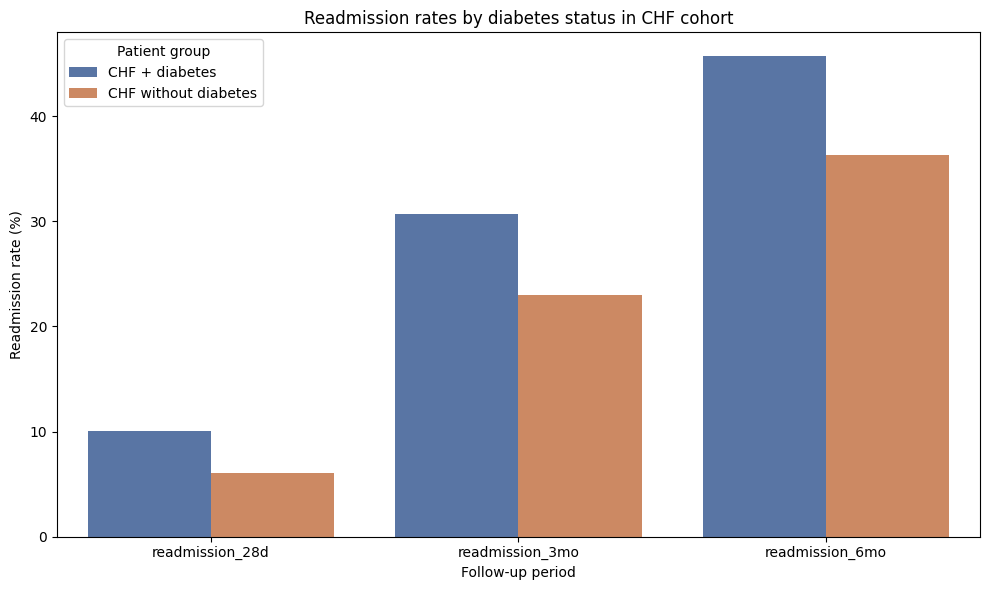

In [6]:
# -----------------------------
# 3. Plot grouped bar chart
# -----------------------------
plot_df = rate_table.melt(id_vars="group", var_name="Outcome", value_name="Rate")

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Outcome", y="Rate", hue="group", palette=["#4C72B0", "#DD8452"])
plt.title("Readmission rates by diabetes status in CHF cohort")
plt.xlabel("Follow-up period")
plt.ylabel("Readmission rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Patient group")
plt.tight_layout()
plt.show()

## ***Q4.Which combinations of recorded conditions occur most often among readmitted patients, helping define groups for a pilot program?***
##### *Reasoning:This helps to come up with a follow-up program targeting high-risk clusters rather than all patients equally*

In [7]:
# -----------------------------
# 1. Define readmitted patients
# -----------------------------
readmission_cols = ["readmission_28d", "readmission_3mo", "readmission_6mo"]
for col in readmission_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# A patient is considered readmitted if they had any readmission during follow-up
df["readmitted_any"] = df[readmission_cols].max(axis=1)

readmitted = df[df["readmitted_any"] == 1].copy()

# -----------------------------
# 2. Select key comorbidity columns
# -----------------------------
condition_cols = [
    "diabetes",
    "mod_severe_ckd",
    "copd",
    "dementia",
    "cerebrovascular_disease",
    "connective_tissue_disease",
    "peptic_ulcer_disease",
    "malignant_lymphoma",
    "solid_tumor",
    "liver_disease",
    "aids"
]

for col in condition_cols:
    if col in df.columns:
        readmitted[col] = pd.to_numeric(readmitted[col], errors="coerce").fillna(0)

# -----------------------------
# 3. Build condition combinations
# -----------------------------
# Keep only condition columns with value 1 = present
readmitted["condition_set"] = readmitted[condition_cols].astype(int).apply(
    lambda row: tuple(col for col, val in zip(condition_cols, row) if val == 1),
    axis=1
)

# Count combinations
combo_counts = readmitted["condition_set"].value_counts().reset_index()
combo_counts.columns = ["condition_combo", "count"]

# Remove empty combinations if any
combo_counts = combo_counts[combo_counts["condition_combo"].astype(str) != "()"]

# Keep the most common combinations for interpretation
top_combinations = combo_counts.head(10).copy()
print("Top condition combinations among readmitted patients:")
print(top_combinations)



Top condition combinations among readmitted patients:
                                      condition_combo  count
1                                         (diabetes,)     90
2                                   (mod_severe_ckd,)     88
3                          (diabetes, mod_severe_ckd)     61
4                                             (copd,)     40
5                                         (dementia,)     36
6                          (cerebrovascular_disease,)     21
7                              (mod_severe_ckd, copd)     17
8                                    (diabetes, copd)     14
9                                    (liver_disease,)     12
10  (diabetes, mod_severe_ckd, cerebrovascular_dis...     10


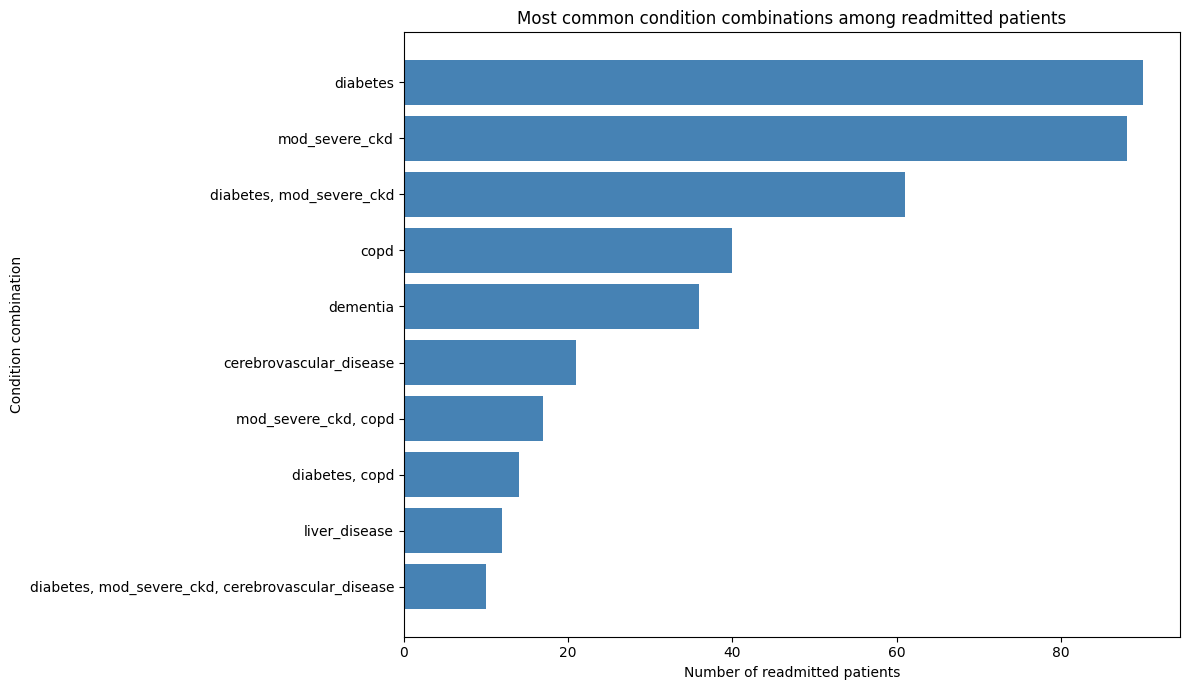

In [8]:
# -----------------------------
# 4. Prepare labels for plotting
# -----------------------------
top_combinations["label"] = top_combinations["condition_combo"].apply(
    lambda x: ", ".join(x) if len(x) > 0 else "No recorded condition"
)

# -----------------------------
# 5. Plot: top combinations
# -----------------------------
plt.figure(figsize=(12, 7))
plt.barh(top_combinations["label"][::-1], top_combinations["count"][::-1], color="steelblue")
plt.title("Most common condition combinations among readmitted patients")
plt.xlabel("Number of readmitted patients")
plt.ylabel("Condition combination")
plt.tight_layout()
plt.show()

## ***Q5.Do higher NYHA classes identify patients for whom the existing discharge and follow-up process should be reviewed?***
##### *Reasoning:This analysis checks whether patients with higher proxy severity scores also have higher short-term readmission or mortality rates.*

In [9]:
# -----------------------------
# 1. Prepare outcome variables
# -----------------------------
for col in ["readmission_28d", "readmission_3mo", "readmission_6mo", "mortality_28d", "death_3mo"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["poor_outcome"] = df[["readmission_28d", "mortality_28d", "readmission_3mo", "death_3mo", "readmission_6mo"]].max(axis=1)

# -----------------------------
# 2. Build a NYHA-like severity proxy
# -----------------------------
# Reasoning:
# - oxygen_use / resp_support suggest greater HF burden and instability
# - longer discharge_day indicates prolonged instability / delayed recovery
# - lower GCS marks more severe acuity / altered consciousness
# - elevated BNP reflects heart failure severity
df["oxygen_yes"] = df["oxygen_use"].fillna("").astype(str).str.contains("oxygen|vent|support", case=False, na=False).astype(int)
df["resp_support_yes"] = df["resp_support"].fillna("").astype(str).str.strip().ne("").astype(int)
df["discharge_day"] = pd.to_numeric(df["discharge_day"], errors="coerce").fillna(0)
df["gcs"] = pd.to_numeric(df["gcs"], errors="coerce").fillna(15)
df["bnp"] = pd.to_numeric(df["bnp"], errors="coerce").fillna(0)

df["nyha_proxy_score"] = (
    2 * df["oxygen_yes"]
    + 2 * df["resp_support_yes"]
    + 1 * (df["discharge_day"] > 7).astype(int)
    + 1 * (df["gcs"] < 15).astype(int)
    + 1 * (df["bnp"] > 400).astype(int)
)

# Map score to NYHA-style groups
bins = [-1, 0, 1, 3, 6, 99]
labels = ["I", "II", "III", "IV", "IV+"]
df["nyha_group"] = pd.cut(df["nyha_proxy_score"], bins=bins, labels=labels, right=True)

# -----------------------------
# 3. Compare outcome rates by NYHA-style class
# -----------------------------
summary = (
    df.groupby("nyha_group")
      .agg(
          patients=("patient_id", "count"),
          readmission_28d=("readmission_28d", "mean"),
          mortality_28d=("mortality_28d", "mean"),
          readmission_3mo=("readmission_3mo", "mean"),
          death_3mo=("death_3mo", "mean"),
          readmission_6mo=("readmission_6mo", "mean"),
          poor_outcome=("poor_outcome", "mean")
      )
      .mul(100)
      .round(2)
)

print("NYHA-style severity summary (proxy classes):")
print(summary)

# Identify classes above median poor-outcome rate for review
review_threshold = summary["poor_outcome"].median()
review_classes = summary[summary["poor_outcome"] >= review_threshold].index.tolist()

print("\nProxy classes above the median poor-outcome rate:")
print(review_classes)



NYHA-style severity summary (proxy classes):
            patients  readmission_28d  mortality_28d  readmission_3mo  \
nyha_group                                                              
I               2700             0.00           0.00             3.70   
II              5200             5.77           0.00            25.00   
III           120100             7.08           1.67            23.31   
IV             71800             7.10           2.23            27.99   
IV+             1000            10.00          10.00            30.00   

            death_3mo  readmission_6mo  poor_outcome  
nyha_group                                            
I                0.00            29.63         29.63  
II               0.00            46.15         46.15  
III              1.75            37.22         39.05  
IV               2.79            40.53         43.59  
IV+             10.00            30.00         40.00  

Proxy classes above the median poor-outcome rate:
['II', 

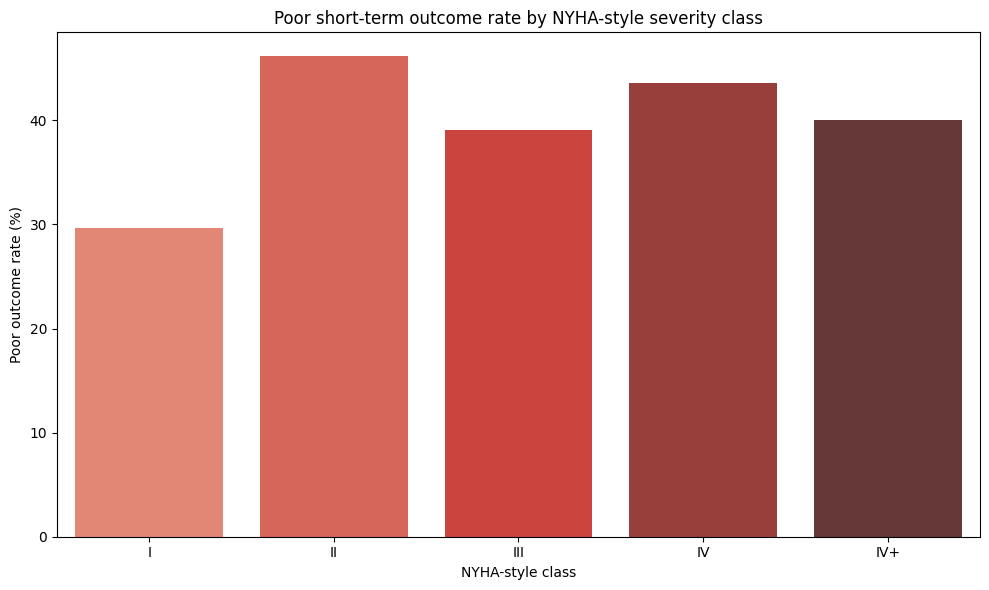

In [10]:
# -----------------------------
# 4. Plot outcome burden by class
# -----------------------------
plot_df = summary[["poor_outcome"]].reset_index().rename(
    columns={"nyha_group": "NYHA_proxy_class", "poor_outcome": "Poor outcome rate (%)"}
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="NYHA_proxy_class", y="Poor outcome rate (%)", palette="Reds_d")
plt.title("Poor short-term outcome rate by NYHA-style severity class")
plt.xlabel("NYHA-style class")
plt.ylabel("Poor outcome rate (%)")
plt.tight_layout()
plt.show()

## ***Q6.Do higher Killip grades identify groups with higher short-term adverse outcome rates that warrant closer process review?***
##### *Reasoning:Killip classification is a standard HF severity grading system.Higher Killip classes reflect greater congestion and instability, so they should be associated with worse short-term outcomes. If that happens, patients in those groups should trigger a closer review of discharge planning, follow-up, and monitoring.*

Short-term adverse outcome rates by Killip-style group (%)
              patients  readmission_28d  mortality_28d  readmission_3mo  \
killip_group                                                              
Killip I          2700             0.00           0.00             3.70   
Killip II         5200             5.77           0.00            25.00   
Killip III      120100             7.08           1.67            23.31   
Killip IV        71800             7.10           2.23            27.99   
Killip IV+        1000            10.00          10.00            30.00   

              death_3mo  readmission_6mo  poor_outcome  
killip_group                                            
Killip I           0.00            29.63         29.63  
Killip II          0.00            46.15         46.15  
Killip III         1.75            37.22         39.05  
Killip IV          2.79            40.53         43.59  
Killip IV+        10.00            30.00         40.00  

Killip groups a

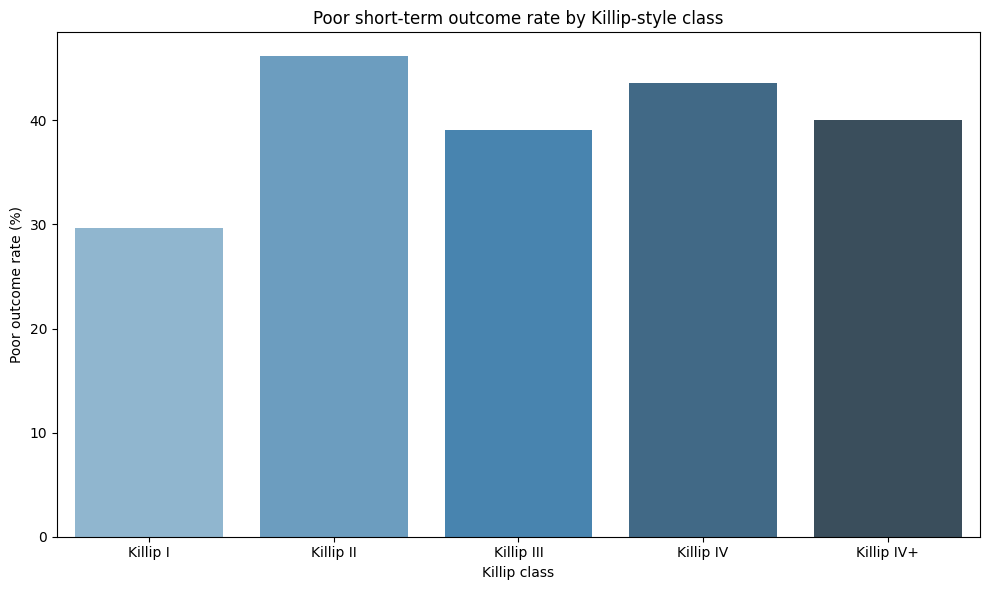

In [11]:
# -----------------------------
# 1. Prepare outcome variables
# -----------------------------
for col in ["readmission_28d", "readmission_3mo", "readmission_6mo", "mortality_28d", "death_3mo"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["poor_outcome"] = df[["readmission_28d", "mortality_28d", "readmission_3mo", "death_3mo", "readmission_6mo"]].max(axis=1)

# -----------------------------
# 2. Create a Killip-style severity proxy
# -----------------------------
# The dataset has no explicit Killip grade, so we approximate it using severity markers
# that align with higher Killip classes:
# - oxygen requirement / respiratory support
# - longer discharge_day suggests ongoing instability
# - low GCS indicates more severe clinical status
# - elevated BNP reflects greater heart-failure burden
df["oxygen_yes"] = df["oxygen_use"].fillna("").astype(str).str.contains("oxygen|vent|support", case=False, na=False).astype(int)
df["resp_support_yes"] = df["resp_support"].fillna("").astype(str).str.strip().ne("").astype(int)
df["discharge_day"] = pd.to_numeric(df["discharge_day"], errors="coerce").fillna(0)
df["gcs"] = pd.to_numeric(df["gcs"], errors="coerce").fillna(15)
df["bnp"] = pd.to_numeric(df["bnp"], errors="coerce").fillna(0)

df["killip_proxy_score"] = (
    2 * df["oxygen_yes"]
    + 2 * df["resp_support_yes"]
    + 1 * (df["discharge_day"] > 7).astype(int)
    + 1 * (df["gcs"] < 15).astype(int)
    + 1 * (df["bnp"] > 400).astype(int)
)

# Map to Killip-style classes
bins = [-1, 0, 1, 3, 6, 99]
labels = ["Killip I", "Killip II", "Killip III", "Killip IV", "Killip IV+"]
df["killip_group"] = pd.cut(df["killip_proxy_score"], bins=bins, labels=labels, right=True)

# -----------------------------
# 3. Compare short-term adverse outcome rates by Killip group
# -----------------------------
killip_summary = (
    df.groupby("killip_group")
      .agg(
          patients=("patient_id", "count"),
          readmission_28d=("readmission_28d", "mean"),
          mortality_28d=("mortality_28d", "mean"),
          readmission_3mo=("readmission_3mo", "mean"),
          death_3mo=("death_3mo", "mean"),
          readmission_6mo=("readmission_6mo", "mean"),
          poor_outcome=("poor_outcome", "mean")
      )
      .mul(100)
      .round(2)
)

print("Short-term adverse outcome rates by Killip-style group (%)")
print(killip_summary)

# Review threshold: groups at or above median poor-outcome rate
review_threshold = killip_summary["poor_outcome"].median()
review_groups = killip_summary[killip_summary["poor_outcome"] >= review_threshold].index.tolist()
print("\nKillip groups above the median poor-outcome rate:")
print(review_groups)

# -----------------------------
# 4. Plot poor outcome rate by Killip group
# -----------------------------
plot_df = killip_summary[["poor_outcome"]].reset_index().rename(
    columns={"killip_group": "Killip_group", "poor_outcome": "Poor outcome rate (%)"}
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Killip_group", y="Poor outcome rate (%)", palette="Blues_d")
plt.title("Poor short-term outcome rate by Killip-style class")
plt.xlabel("Killip class")
plt.ylabel("Poor outcome rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Interpretation
# -----------------------------
# If higher Killip-style classes show higher short-term readmission and mortality,
# then they identify a group where the current discharge and follow-up process should
# be reviewed and strengthened.

## ***Q7.Does recorded myocardial infarction status identify a group with higher 28-day readmission rates?***
##### *Reasoning: Myocardial infarction is a major clinical risk factor for recurrent heart-failure events. If the MI group has a higher 28-day readmission rate, it indicates that MI history should be considered when prioritizing discharge planning and early follow-up.*

28-day readmission rate by myocardial infarction status:
  mi_status  28-day readmission rate (%)
0        MI                         8.39
1     No MI                         6.86


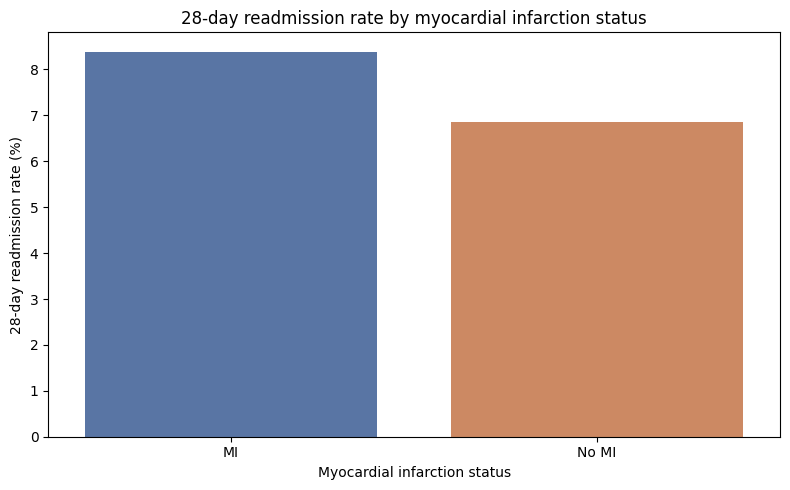

In [12]:
# -----------------------------
# 1. Acquire MI status from the merged HF dataset 
# -----------------------------
# 
if "myocardial_infarction" in hf_df.columns:
    df = hf_df.copy()
else:
    cardiac = pd.read_csv("cleaned_files/cardiac_cleaned.csv")
    df = hf_df.merge(cardiac[["patient_id", "myocardial_infarction"]], on="patient_id", how="left")

# -----------------------------
# 2. Clean variables
# -----------------------------
df["readmission_28d"] = pd.to_numeric(df["readmission_28d"], errors="coerce").fillna(0)
df["myocardial_infarction"] = pd.to_numeric(df["myocardial_infarction"], errors="coerce").fillna(0)

df["mi_status"] = df["myocardial_infarction"].map({0: "No MI", 1: "MI"})

# -----------------------------
# 3. Compare 28-day readmission rates by MI status
# -----------------------------
summary = (
    df.groupby("mi_status")["readmission_28d"]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
      .rename(columns={"readmission_28d": "28-day readmission rate (%)"})
)

print("28-day readmission rate by myocardial infarction status:")
print(summary)

# -----------------------------
# 4. Plot: readmission by MI status
# -----------------------------
plt.figure(figsize=(8, 5))
sns.barplot(data=summary, x="mi_status", y="28-day readmission rate (%)", palette=["#4C72B0", "#DD8452"])
plt.title("28-day readmission rate by myocardial infarction status")
plt.xlabel("Myocardial infarction status")
plt.ylabel("28-day readmission rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Interpretation
# -----------------------------
# If the MI group has a meaningfully higher 28-day readmission rate than the non-MI group,
# then recorded myocardial infarction status should be used to flag patients for tighter
# discharge review and earlier follow-up.


## ***Q8.Do heart failure types (Left, Right, Both) differ in readmission rates enough to justify reviewing whether follow-up processes meet each group’s needs?***
##### *Reasoning:This compares readmission rates across Left, Right, and Both heart-failure types and checks whether the differences are large enough to justify reviewing whether follow-up pathways are tailored by subtype*

In [13]:
# Read only the merged HF dataset
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# Keep the working data
df = hf_df.copy()

# Clean heart failure type labels
df["heart_failure_type"] = df["heart_failure_type"].astype(str).str.strip().str.lower()

# Keep only the clinically relevant groups
valid_types = ["left", "right", "both"]
df = df[df["heart_failure_type"].isin(valid_types)].copy()

# Clean readmission columns
for col in ["readmission_28d", "readmission_3mo", "readmission_6mo"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Any readmission flag
df["readmitted_any"] = df[["readmission_28d", "readmission_3mo", "readmission_6mo"]].max(axis=1)

# Summarize by heart-failure type
summary = (
    df.groupby("heart_failure_type")
      .agg(
          patients=("patient_id", "count"),
          readmission_28d=("readmission_28d", "mean"),
          readmission_3mo=("readmission_3mo", "mean"),
          readmission_6mo=("readmission_6mo", "mean"),
          any_readmission=("readmitted_any", "mean")
      )
      .mul(100)
      .round(2)
      .reset_index()
)

print("Readmission rate by heart failure type (%)")
print(summary)


Readmission rate by heart failure type (%)
  heart_failure_type  patients  readmission_28d  readmission_3mo  \
0               both    148000             7.84            27.43   
1               left     47700             4.61            17.19   
2              right      5100             3.92            19.61   

   readmission_6mo  any_readmission  
0            42.23            42.43  
1            27.25            27.25  
2            35.29            35.29  


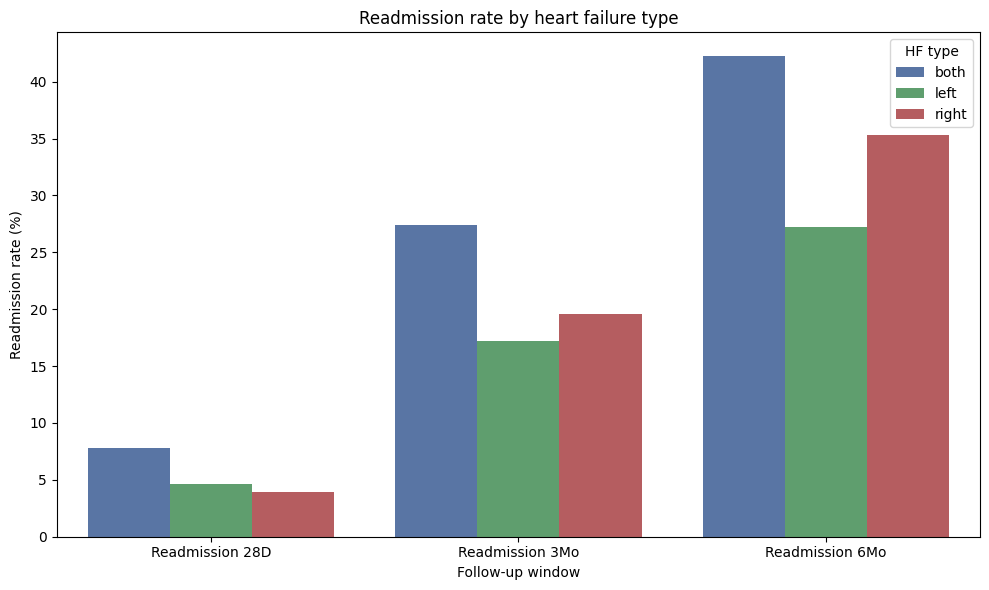

In [14]:
# Prepare plot data
plot_df = summary.melt(
    id_vars="heart_failure_type",
    value_vars=["readmission_28d", "readmission_3mo", "readmission_6mo"],
    var_name="Follow_up_window",
    value_name="Rate"
)

plot_df["Follow_up_window"] = plot_df["Follow_up_window"].str.replace("_", " ").str.title()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="Follow_up_window",
    y="Rate",
    hue="heart_failure_type",
    palette=["#4C72B0", "#55A868", "#C44E52"]
)
plt.title("Readmission rate by heart failure type")
plt.xlabel("Follow-up window")
plt.ylabel("Readmission rate (%)")
plt.xticks(rotation=0)
plt.legend(title="HF type")
plt.tight_layout()
plt.show()

## ***Q9.Among patients with an LVEF measurement, do readmission rates differ across LVEF groups, and would collecting LVEF more consistently improve analysis?***
##### *Reasoning:This code compares readmission rates across LVEF groups and also checks how often LVEF is missing, which helps answer whether more consistent LVEF collection would improve the analysis.*

Readmission rates by LVEF group (%)
       lvef_group  patients  readmission_28d  readmission_3mo  readmission_6mo
0     HFrEF (<40)     13200             6.06            26.52            43.18
1  HFmrEF (40-49)     15200             5.26            20.39            36.18
2    HFpEF (>=50)    172400             7.19            25.06            38.34


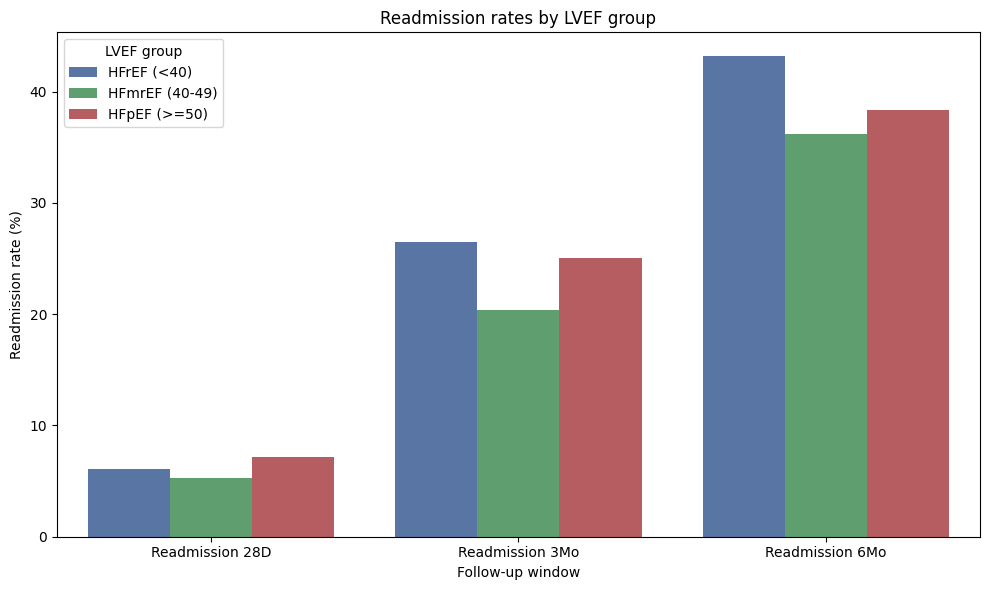


Percentage of patients with missing LVEF: 0.00%


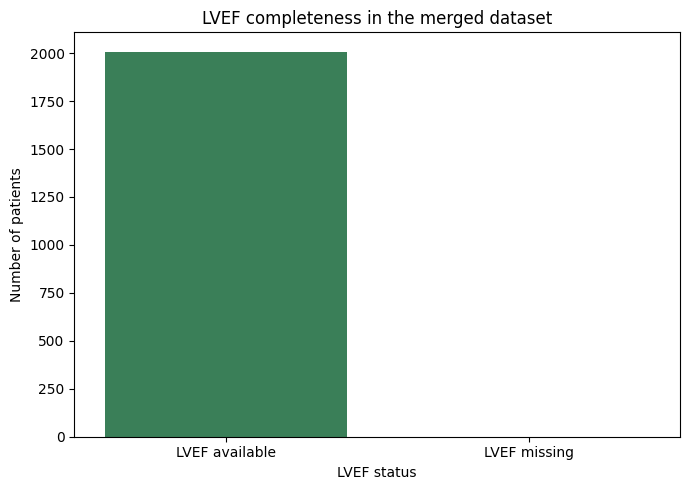

In [15]:
# Load merged dataset
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# Keep a working copy
df = hf_df.copy()

# -----------------------------
# 1. Clean LVEF variable
# -----------------------------
df["lvef"] = pd.to_numeric(df["lvef"], errors="coerce")

# Keep only patients with an LVEF measurement
analysis_df = df.dropna(subset=["lvef"]).copy()

# Define clinically meaningful EF groups
# HFrEF: < 40
# HFmrEF: 40 to 49
# HFpEF: >= 50
analysis_df["lvef_group"] = pd.cut(
    analysis_df["lvef"],
    bins=[-1, 39, 49, 100],
    labels=["HFrEF (<40)", "HFmrEF (40-49)", "HFpEF (>=50)"],
    right=True
)

# -----------------------------
# 2. Clean readmission variables
# -----------------------------
for col in ["readmission_28d", "readmission_3mo", "readmission_6mo"]:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce").fillna(0)

# -----------------------------
# 3. Summarize readmission rates by LVEF group
# -----------------------------
summary = (
    analysis_df.groupby("lvef_group")
      .agg(
          patients=("patient_id", "count"),
          readmission_28d=("readmission_28d", "mean"),
          readmission_3mo=("readmission_3mo", "mean"),
          readmission_6mo=("readmission_6mo", "mean")
      )
      .mul(100)
      .round(2)
      .reset_index()
)

print("Readmission rates by LVEF group (%)")
print(summary)

# -----------------------------
# 4. Plot: readmission rate by LVEF group
# -----------------------------
plot_df = summary.melt(
    id_vars="lvef_group",
    value_vars=["readmission_28d", "readmission_3mo", "readmission_6mo"],
    var_name="Follow_up_window",
    value_name="Rate"
)

plot_df["Follow_up_window"] = plot_df["Follow_up_window"].str.replace("_", " ").str.title()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="Follow_up_window",
    y="Rate",
    hue="lvef_group",
    palette=["#4C72B0", "#55A868", "#C44E52"]
)
plt.title("Readmission rates by LVEF group")
plt.xlabel("Follow-up window")
plt.ylabel("Readmission rate (%)")
plt.xticks(rotation=0)
plt.legend(title="LVEF group")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Missing LVEF check
# -----------------------------
missing_lvef = df["lvef"].isna().mean() * 100
print(f"\nPercentage of patients with missing LVEF: {missing_lvef:.2f}%")

missing_df = pd.DataFrame({
    "status": ["LVEF available", "LVEF missing"],
    "count": [
        df["lvef"].notna().sum(),
        df["lvef"].isna().sum()
    ]
})

plt.figure(figsize=(7, 5))
sns.barplot(data=missing_df, x="status", y="count", palette=["#2E8B57", "#D95F02"])
plt.title("LVEF completeness in the merged dataset")
plt.xlabel("LVEF status")
plt.ylabel("Number of patients")
plt.tight_layout()
plt.show()

## ***Q10.Which combinations of cardiac findings and prior conditions have the highest observed readmission rates, and are those groups large enough for a targeted follow-up pilot?***
##### *Reasoning:This code looks for the combinations that have the highest observed readmission rates, then checks whether those groups are large enough to support a targeted follow-up pilot*

Pilot-ready combinations with highest readmission rates:
                        risk_combo  n_patients  readmission_28d  \
62   CHF + HFpEF + Dementia + Both          55            0.018   
46   CHF + HFpEF + DM + CKD + Both          80            0.138   
45         CHF + HFpEF + DM + Both         114            0.105   
107                   HFpEF + Both          59            0.153   
35        CHF + HFpEF + CKD + Left          48            0.042   
27        CHF + HFpEF + CKD + Both         106            0.094   
26              CHF + HFpEF + Both         466            0.064   
113             HFpEF + CVD + Both          23            0.043   
67              CHF + HFrEF + Both          44            0.023   
37       CHF + HFpEF + COPD + Both          53            0.038   

     readmission_3mo  readmission_6mo  any_readmission  
62             0.218            0.509            0.527  
46             0.325            0.475            0.488  
45             0.316            0.

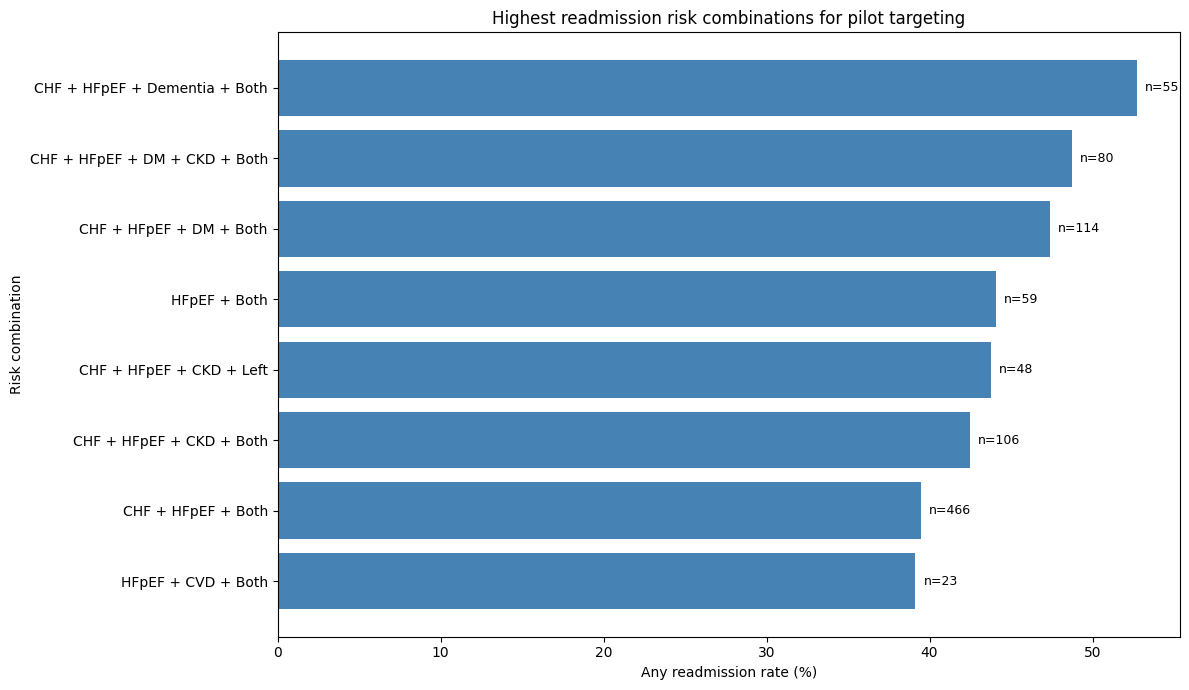

In [16]:
# -----------------------------
# 1. Clean key clinical variables
# -----------------------------
numeric_cols = [
    "readmission_28d", "readmission_3mo", "readmission_6mo",
    "myocardial_infarction", "congestive_heart_failure", "peripheral_vascular_disease",
    "diabetes", "mod_severe_ckd", "copd", "dementia", "cerebrovascular_disease",
    "lvef", "nyha_cardiac_function_classification", "killip_grade"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# LVEF group for clinical context
df["lvef_group"] = pd.cut(
    df["lvef"],
    bins=[-1, 39, 49, 100],
    labels=["HFrEF", "HFmrEF", "HFpEF"],
    right=True
)

# Heart failure type label
df["heart_failure_type"] = df["heart_failure_type"].fillna("unknown").astype(str).str.lower()

# Binary any-readmission flag
df["readmitted_any"] = (df[["readmission_28d", "readmission_3mo", "readmission_6mo"]].max(axis=1) > 0).astype(int)

# -----------------------------
# 2. Create a combined risk profile label
# -----------------------------
def build_risk_combo(row):
    flags = []

    # Cardiac findings
    if row["myocardial_infarction"] == 1:
        flags.append("MI")
    if row["congestive_heart_failure"] == 1:
        flags.append("CHF")
    if row["peripheral_vascular_disease"] == 1:
        flags.append("PVD")
    if row["lvef_group"] == "HFrEF":
        flags.append("HFrEF")
    elif row["lvef_group"] == "HFmrEF":
        flags.append("HFmrEF")
    elif row["lvef_group"] == "HFpEF":
        flags.append("HFpEF")

    # Prior conditions
    if row["diabetes"] == 1:
        flags.append("DM")
    if row["mod_severe_ckd"] == 1:
        flags.append("CKD")
    if row["copd"] == 1:
        flags.append("COPD")
    if row["dementia"] == 1:
        flags.append("Dementia")
    if row["cerebrovascular_disease"] == 1:
        flags.append("CVD")

    # Optional subtype
    if row["heart_failure_type"] in ["left", "right", "both"]:
        flags.append(row["heart_failure_type"].title())

    return " + ".join(flags) if flags else "No major flags"

df["risk_combo"] = df.apply(build_risk_combo, axis=1)

# -----------------------------
# 3. Summarize readmission by risk combination
# -----------------------------
combo_summary = (
    df.groupby("risk_combo")
      .agg(
          n_patients=("patient_id", "count"),
          readmission_28d=("readmission_28d", "mean"),
          readmission_3mo=("readmission_3mo", "mean"),
          readmission_6mo=("readmission_6mo", "mean"),
          any_readmission=("readmitted_any", "mean")
      )
      .reset_index()
)

# Keep only combinations with meaningful sample size for pilot planning
pilot_threshold = 20
pilot_candidates = combo_summary[combo_summary["n_patients"] >= pilot_threshold].copy()

# Rank by any readmission rate
pilot_candidates = pilot_candidates.sort_values("any_readmission", ascending=False).head(10)

print("Pilot-ready combinations with highest readmission rates:")
print(pilot_candidates.round(3))

# -----------------------------
# 4. Plot: top combinations
# -----------------------------
plot_df = pilot_candidates.sort_values("any_readmission", ascending=False).head(8).copy()

plt.figure(figsize=(12, 7))
bars = plt.barh(
    plot_df["risk_combo"][::-1],
    plot_df["any_readmission"][::-1] * 100,
    color="steelblue"
)

plt.title("Highest readmission risk combinations for pilot targeting")
plt.xlabel("Any readmission rate (%)")
plt.ylabel("Risk combination")

# Add patient count labels
for bar, n in zip(bars, plot_df["n_patients"][::-1]):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"n={n}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### ***11. Among patients with a recorded GFR, are some groups readmitted more often, and should renal-related follow-up processes be reviewed?***
 
 Reasoning: 
 
 Among heart-failure patients with recorded GFR, lower kidney function groups are expected to have higher 28-day readmission risk. If readmissions rise as GFR declines, this suggests renal follow-up processes may need improvement. The practical action is to strengthen kidney-focused discharge care: early post-discharge labs, medication review, quicker specialist follow-up, and closer home monitoring. This turns a risk pattern into a clear process-improvement decision.


Q11 Prescriptive Summary (Recorded GFR only)
Overall 28-day readmission rate: 7.04%



,gfr_group,total_patients,readmitted_patients,readmit_rate_pct,review_renal_followup,prescriptive_action
0,Severe (<30),252,20,7.94,YES,"Strengthen renal follow-up: 72h lab check, med..."
1,Moderate (30-59),634,65,10.25,YES,"Strengthen renal follow-up: 72h lab check, med..."
2,Mild (60-89),568,27,4.75,NO,Standard discharge follow-up
3,Normal (>=90),491,25,5.09,NO,Standard discharge follow-up


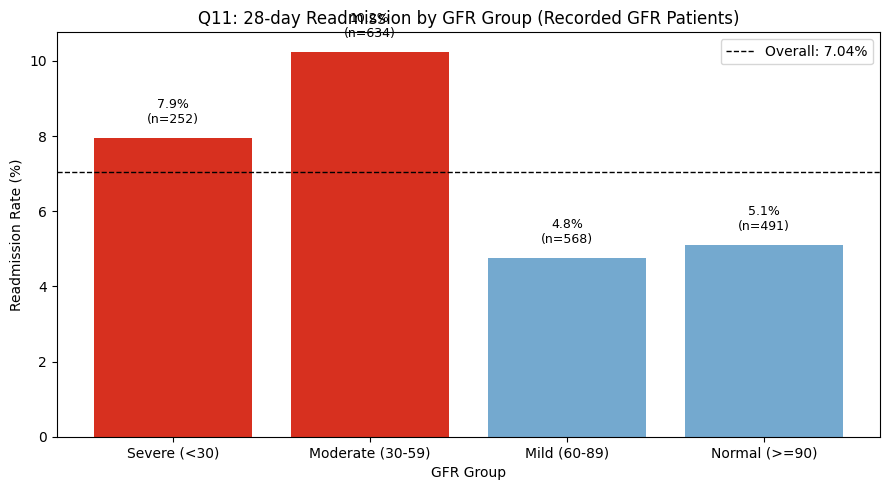

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load data ----------
# Reuse df if already loaded; otherwise read from file
if "df" not in globals():
    df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# ---------- Resolve columns ----------
readmit_col = "readmission_28d" if "readmission_28d" in df.columns else (
    "readmitted_within_28_days" if "readmitted_within_28_days" in df.columns else None
)
if readmit_col is None:
    raise ValueError("Readmission column not found (readmission_28d / readmitted_within_28_days).")

if "gfr" not in df.columns:
    raise ValueError("gfr column not found.")

# ---------- Helper ----------
def to_bin(s: pd.Series) -> pd.Series:
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().any():
        return num.fillna(0).astype(int).clip(0, 1)
    txt = s.astype("string").str.strip().str.lower()
    return txt.isin(["1", "yes", "y", "true"]).astype(int)

# ---------- Main logic (readmitted patients focus) ----------
work = df.copy()
work["gfr"] = pd.to_numeric(work["gfr"], errors="coerce")
work["readmit_28d_bin"] = to_bin(work[readmit_col])

# Keep only patients with recorded GFR
sub = work[work["gfr"].notna()].copy()

# Clinical GFR groups
bins = [-np.inf, 30, 60, 90, np.inf]
labels = ["Severe (<30)", "Moderate (30-59)", "Mild (60-89)", "Normal (>=90)"]
sub["gfr_group"] = pd.cut(sub["gfr"], bins=bins, labels=labels, right=False)

# Group performance
grp = (
    sub.groupby("gfr_group", dropna=False)["readmit_28d_bin"]
    .agg(readmit_rate="mean", readmitted_patients="sum", total_patients="count")
    .reset_index()
)

grp["readmit_rate_pct"] = (grp["readmit_rate"] * 100).round(2)
overall_rate_pct = round(sub["readmit_28d_bin"].mean() * 100, 2)

# Prescriptive flag: review renal process if group rate is above overall
grp["review_renal_followup"] = np.where(
    grp["readmit_rate_pct"] > overall_rate_pct, "YES", "NO"
)

# Suggested action per group
grp["prescriptive_action"] = np.where(
    grp["review_renal_followup"] == "YES",
    "Strengthen renal follow-up: 72h lab check, med review, early clinic call",
    "Standard discharge follow-up"
)

print("Q11 Prescriptive Summary (Recorded GFR only)")
print(f"Overall 28-day readmission rate: {overall_rate_pct}%\n")
display(grp[["gfr_group", "total_patients", "readmitted_patients", "readmit_rate_pct", "review_renal_followup", "prescriptive_action"]])

# ---------- Simple chart ----------
plot_df = grp.copy()
plot_df["color"] = np.where(plot_df["review_renal_followup"] == "YES", "#d7301f", "#74a9cf")

plt.figure(figsize=(9, 5))
bars = plt.bar(plot_df["gfr_group"].astype(str), plot_df["readmit_rate_pct"], color=plot_df["color"])
plt.axhline(overall_rate_pct, linestyle="--", color="black", linewidth=1, label=f"Overall: {overall_rate_pct}%")

for i, r in plot_df.iterrows():
    plt.text(i, r["readmit_rate_pct"] + 0.4, f"{r['readmit_rate_pct']:.1f}%\n(n={int(r['total_patients'])})",
             ha="center", fontsize=9)

plt.title("Q11: 28-day Readmission by GFR Group (Recorded GFR Patients)")
plt.xlabel("GFR Group")
plt.ylabel("Readmission Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

Insights:

Readmission burden is concentrated in lower GFR groups (especially severe/moderate renal dysfunction), while higher GFR groups show relatively lower rates. This indicates a clear kidney-function gradient in 28-day readmission risk.

Prescriptive implication: For GFR groups above the overall readmission benchmark, renal follow-up should be intensified (early lab recheck, medication reconciliation, and faster post-discharge review), while lower-risk groups can continue standard follow-up.



### ***12.Do patients with different brain natriuretic peptide levels have different readmission rates, and is the measurement available often enough to support a useful analysis?***

Reasoning:

Higher BNP levels usually indicate greater heart-failure severity, so those groups are expected to have higher 28-day readmission rates.
Check BNP data completeness first: if coverage is good, BNP can be used to stratify follow-up intensity.

If missingness is high, BNP should be used as a supportive marker alongside other reliable risk variables, not as a standalone trigger.

Q12 Prescriptive Summary (BNP and 28-day readmission)
BNP availability: 98.26%
Overall readmission rate (BNP-recorded cohort): 6.89%



,bnp_group,total_patients,readmitted_patients,readmit_rate_pct,review_followup_process,prescriptive_action
0,Q1 (Lowest BNP),494,36,7.29,YES,"Intensify follow-up: 48-72h call, med/fluid re..."
1,Q2,493,18,3.65,NO,Standard follow-up
2,Q3,493,44,8.92,YES,"Intensify follow-up: 48-72h call, med/fluid re..."
3,Q4 (Highest BNP),493,38,7.71,YES,"Intensify follow-up: 48-72h call, med/fluid re..."


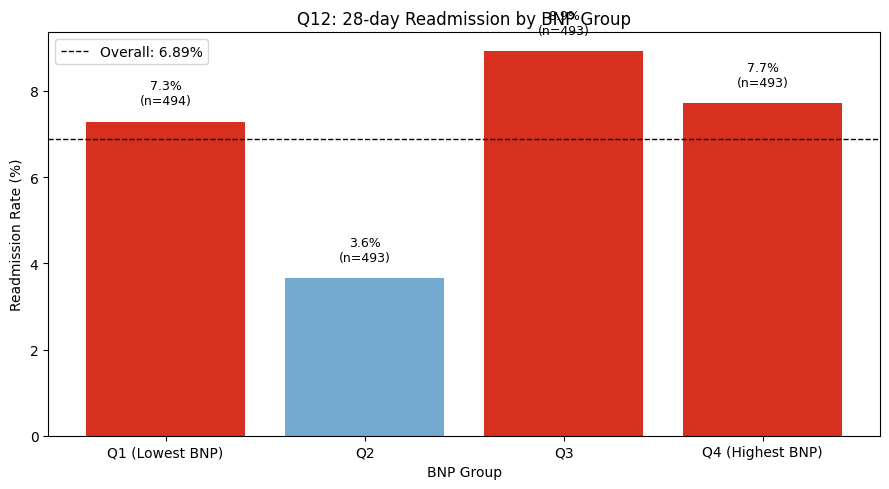

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load data ----------
if "df" not in globals():
    df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# ---------- Resolve columns ----------
readmit_col = "readmission_28d" if "readmission_28d" in df.columns else (
    "readmitted_within_28_days" if "readmitted_within_28_days" in df.columns else None
)
if readmit_col is None:
    raise ValueError("Readmission column not found (readmission_28d / readmitted_within_28_days).")

bnp_col = "bnp" if "bnp" in df.columns else ("BNP" if "BNP" in df.columns else None)
if bnp_col is None:
    raise ValueError("BNP column not found (bnp / BNP).")

# ---------- Helper ----------
def to_bin(s: pd.Series) -> pd.Series:
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().any():
        return num.fillna(0).astype(int).clip(0, 1)
    txt = s.astype("string").str.strip().str.lower()
    return txt.isin(["1", "yes", "y", "true"]).astype(int)

# ---------- Main logic ----------
work = df.copy()
work[bnp_col] = pd.to_numeric(work[bnp_col], errors="coerce")
work["readmit_28d_bin"] = to_bin(work[readmit_col])

# BNP availability
coverage_pct = round(100 * work[bnp_col].notna().mean(), 2)

# Keep only patients with recorded BNP
sub = work[work[bnp_col].notna()].copy()
if sub.empty:
    raise ValueError("No patients with recorded BNP.")

# BNP groups: quartiles if possible, else clinical bins
if sub[bnp_col].nunique() >= 4:
    sub["bnp_group"] = pd.qcut(
        sub[bnp_col],
        q=4,
        labels=["Q1 (Lowest BNP)", "Q2", "Q3", "Q4 (Highest BNP)"],
        duplicates="drop"
    )
else:
    bins = [-np.inf, 100, 400, 1000, np.inf]
    labels = ["Low (<100)", "Mild-Moderate (100-399)", "High (400-999)", "Very High (>=1000)"]
    sub["bnp_group"] = pd.cut(sub[bnp_col], bins=bins, labels=labels, right=False)

# Readmission rates by BNP group
grp = (
    sub.groupby("bnp_group", dropna=False)["readmit_28d_bin"]
       .agg(readmit_rate="mean", readmitted_patients="sum", total_patients="count")
       .reset_index()
)
grp["readmit_rate_pct"] = (grp["readmit_rate"] * 100).round(2)

overall_rate_pct = round(100 * sub["readmit_28d_bin"].mean(), 2)
grp["review_followup_process"] = np.where(grp["readmit_rate_pct"] > overall_rate_pct, "YES", "NO")

# Prescriptive action: depends on BNP coverage + rate signal
coverage_ok = coverage_pct >= 60
grp["prescriptive_action"] = np.where(
    grp["review_followup_process"].eq("YES") & coverage_ok,
    "Intensify follow-up: 48-72h call, med/fluid review, early clinic visit",
    np.where(
        grp["review_followup_process"].eq("YES") & ~coverage_ok,
        "BNP suggests risk, but low coverage: combine with other stable risk markers",
        "Standard follow-up"
    )
)

print("Q12 Prescriptive Summary (BNP and 28-day readmission)")
print(f"BNP availability: {coverage_pct}%")
print(f"Overall readmission rate (BNP-recorded cohort): {overall_rate_pct}%\n")
display(grp[["bnp_group", "total_patients", "readmitted_patients", "readmit_rate_pct", "review_followup_process", "prescriptive_action"]])

# ---------- Simple chart ----------
plot_df = grp.copy()
plot_df["color"] = np.where(plot_df["review_followup_process"].eq("YES"), "#d7301f", "#74a9cf")

plt.figure(figsize=(9, 5))
plt.bar(plot_df["bnp_group"].astype(str), plot_df["readmit_rate_pct"], color=plot_df["color"])
plt.axhline(overall_rate_pct, linestyle="--", color="black", linewidth=1, label=f"Overall: {overall_rate_pct}%")

for i, r in plot_df.iterrows():
    plt.text(i, r["readmit_rate_pct"] + 0.4, f"{r['readmit_rate_pct']:.1f}%\n(n={int(r['total_patients'])})",
             ha="center", fontsize=9)

plt.title("Q12: 28-day Readmission by BNP Group")
plt.xlabel("BNP Group")
plt.ylabel("Readmission Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

Insights:

Higher BNP groups with rates above overall baseline should get stronger follow-up workflows.

If BNP coverage is low, use BNP as a supportive factor with other stable risk markers.


### ***13. Are certain admission vital-sign patterns associated with longer stays, suggesting where care coordination resources might be needed?***

Reasoning:

Certain admission vital-sign patterns (e.g., low systolic BP, high heart rate, low oxygen saturation, fast respiratory rate, fever) often reflect higher initial acuity, clinical instability, or comorbidity burden. These patients are more likely to need extra monitoring, treatment adjustments, and discharge planning, which can increase length of stay (LOS).

Q13 Prescriptive Summary (Admission Vital Patterns vs LOS)
Overall median LOS: 8.0 days



,vital_pattern_group,total_patients,avg_los,median_los,review_care_coordination,prescriptive_action
0,Stable (0 abnormal),1468,9.56,8.0,NO,Standard coordination pathway
1,Mild (1),511,9.04,8.0,NO,Standard coordination pathway
2,Moderate (2),29,8.90,7.0,NO,Standard coordination pathway
3,High (>=3),0,NaN,NaN,NO,Standard coordination pathway


posx and posy should be finite values
posx and posy should be finite values


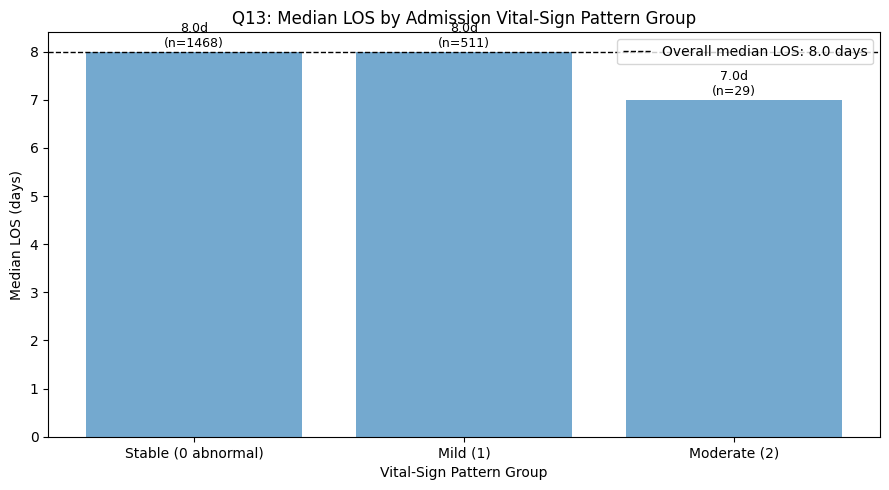

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load ----------
if "df" not in globals():
    df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

work = df.copy()

# ---------- Resolve LOS + vital columns (supports common name variations) ----------
def pick_col(candidates):
    return next((c for c in candidates if c in work.columns), None)

los_col = pick_col(["length_of_stay", "los_days", "LOS", "length_of_stay_days"])
sbp_col = pick_col(["systolic_bp", "sbp", "admission_systolic_bp"])
hr_col  = pick_col(["heart_rate", "hr", "pulse"])
spo2_col = pick_col(["oxygen_saturation", "spo2", "o2_sat"])
rr_col = pick_col(["respiratory_rate", "rr", "resp_rate"])
temp_col = pick_col(["temperature", "temp", "body_temperature"])

if los_col is None:
    los_col = pick_col(["discharge_day", "los", "length_of_stay_days"])
    if los_col is None:
        raise ValueError("LOS column not found (length_of_stay / los_days / LOS / discharge_day).")

# ---------- Numeric cleanup ----------
work[los_col] = pd.to_numeric(work[los_col], errors="coerce")
for c in [sbp_col, hr_col, spo2_col, rr_col, temp_col]:
    if c is not None:
        work[c] = pd.to_numeric(work[c], errors="coerce")

# Keep rows with LOS
sub = work[work[los_col].notna()].copy()

# ---------- Admission abnormal flags ----------
flags = {}
if sbp_col:  flags["low_sbp"] = (sub[sbp_col] < 100).astype(int)
if hr_col:   flags["high_hr"] = (sub[hr_col] > 100).astype(int)
if spo2_col: flags["low_spo2"] = (sub[spo2_col] < 92).astype(int)
if rr_col:   flags["high_rr"] = (sub[rr_col] > 22).astype(int)
if temp_col: flags["fever"] = (sub[temp_col] >= 38.0).astype(int)

if len(flags) == 0:
    raise ValueError("No vital-sign columns found for analysis.")

for k, v in flags.items():
    sub[k] = v

# Risk score = number of abnormal vitals at admission
flag_cols = list(flags.keys())
sub["vital_risk_score"] = sub[flag_cols].sum(axis=1)

# Pattern tiers
sub["vital_pattern_group"] = pd.cut(
    sub["vital_risk_score"],
    bins=[-1, 0, 1, 2, 10],
    labels=["Stable (0 abnormal)", "Mild (1)", "Moderate (2)", "High (>=3)"]
)

# ---------- LOS outcomes by pattern ----------
grp = (
    sub.groupby("vital_pattern_group", dropna=False)[los_col]
       .agg(avg_los="mean", median_los="median", total_patients="count")
       .reset_index()
)

grp["avg_los"] = grp["avg_los"].round(2)
grp["median_los"] = grp["median_los"].round(2)

overall_median_los = round(sub[los_col].median(), 2)

# Prescriptive decision: review care coordination if LOS > overall median LOS
grp["review_care_coordination"] = np.where(grp["median_los"] > overall_median_los, "YES", "NO")
grp["prescriptive_action"] = np.where(
    grp["review_care_coordination"].eq("YES"),
    "Start early care coordination: case manager, multidisciplinary rounds, discharge planning from day 1",
    "Standard coordination pathway"
)

print("Q13 Prescriptive Summary (Admission Vital Patterns vs LOS)")
print(f"Overall median LOS: {overall_median_los} days\n")
display(grp[["vital_pattern_group", "total_patients", "avg_los", "median_los",
             "review_care_coordination", "prescriptive_action"]])

# ---------- Simple chart ----------
plot_df = grp.copy()
plot_df["color"] = np.where(plot_df["review_care_coordination"].eq("YES"), "#d7301f", "#74a9cf")

plt.figure(figsize=(9, 5))
plt.bar(plot_df["vital_pattern_group"].astype(str), plot_df["median_los"], color=plot_df["color"])
plt.axhline(overall_median_los, linestyle="--", color="black", linewidth=1, label=f"Overall median LOS: {overall_median_los} days")

for i, r in plot_df.iterrows():
    plt.text(i, r["median_los"] + 0.1, f"{r['median_los']:.1f}d\n(n={int(r['total_patients'])})",
             ha="center", fontsize=9)

plt.title("Q13: Median LOS by Admission Vital-Sign Pattern Group")
plt.xlabel("Vital-Sign Pattern Group")
plt.ylabel("Median LOS (days)")
plt.legend()
plt.tight_layout()
plt.show()

Key Insights:

1. Stable and Mild groups have the same median LOS: Both groups have a median hospital stay of 8 days, matching the overall median LOS of 8 days, despite differences in vital-sign abnormalities.

2. Moderate abnormality group has a shorter median LOS: This group has a median LOS of 7 days, one day below the overall median, but includes only 29 patients, so the result should be interpreted cautiously.

## ***14. Which patient segments should receive intensive follow-up within 28 days to reduce mortality?***

Patients should get intensive 28-day follow-up when they show patterns linked to early post-discharge death:

--> Hemodynamic instability (low SBP / high pulse / high respiration) → acute risk.

--> Cardiac injury/stress (high hs_troponin, high bnp) → ongoing cardiac risk.

--> Older age / frailty proxies and repeated admissions (visit_count) → higher near-term events.

So, the prescriptive goal is to identify segments with high observed 28-day mortality rate and assign follow-up intensity tiers.

Segment summary:


,followup_tier,patients,deaths_28d,mortality_rate_28d,avg_risk_score
1,Tier-2 Moderate (72h call + 14d clinic),921,28,3.040174,2.135722
2,Tier-3 Standard (routine follow-up),1085,9,0.829493,0.984332
0,Tier-1 Intensive (48h call + 7d clinic),2,0,0.000000,4.000000


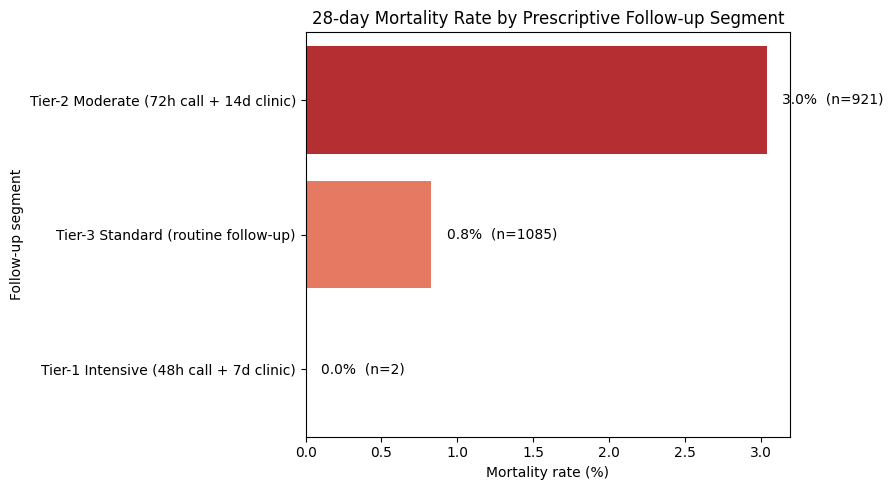

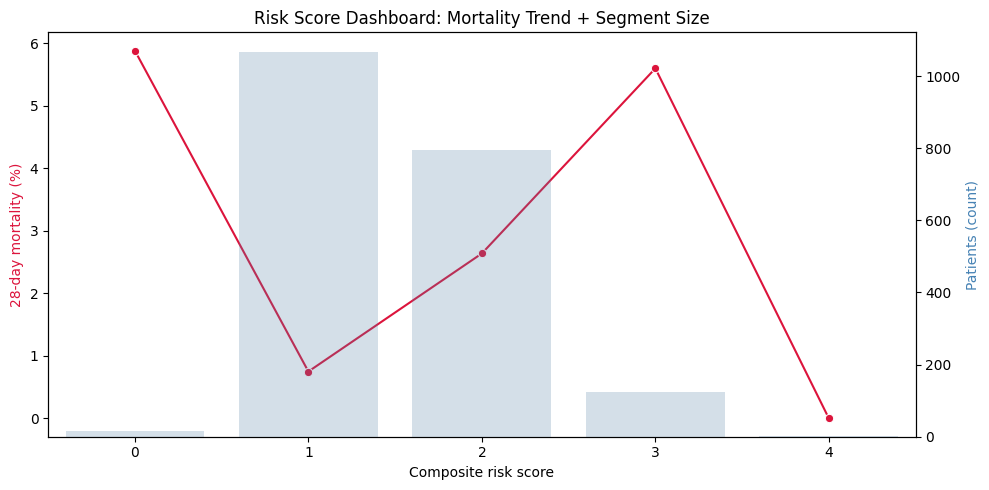

In [20]:
try:
    import pandas as pd
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
    import pandas as pd
import numpy as np
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:

    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns
import sys
import subprocess

# Load merged dataset
df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# ---------- Helpers ----------
def to_binary_outcome(s):
    """
    Convert common outcome encodings to 0/1.
    Handles: 0/1, yes/no, dead/alive, death/survived.
    """
    if s.dtype.kind in "biufc":
        return pd.to_numeric(s, errors="coerce").fillna(0).astype(int).clip(0, 1)
    txt = s.astype("string").str.strip().str.lower()
    death_tokens = {"1", "yes", "y", "dead", "death", "deceased", "true"}
    return txt.isin(death_tokens).astype(int)

def q75(series):
    return series.quantile(0.75) if series.notna().any() else np.nan

# ---------- Outcome column ----------
# Prefer mortality_28d if present, else fallback
if "mortality_28d" in df.columns:
    df["mortality_28d_bin"] = to_binary_outcome(df["mortality_28d"])
elif "death_within_28_days" in df.columns:
    df["mortality_28d_bin"] = to_binary_outcome(df["death_within_28_days"])
else:
    raise ValueError("No 28-day mortality column found.")

# ---------- Build clinically meaningful risk flags ----------
# Numeric conversions (safe)
for c in ["cci_score", "systolic_bp", "pulse", "respiration", "gfr", "creatinine", "hs_troponin", "bnp", "visit_count"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Age high-risk from age_category text if available
if "age_category" in df.columns:
    age_text = df["age_category"].astype("string").str.lower()
    df["risk_age"] = age_text.str.contains("70|75|80|85|90|elder|old", regex=True, na=False).astype(int)
else:
    df["risk_age"] = 0

df["risk_cci"] = (df["cci_score"] >= 5).astype(int) if "cci_score" in df.columns else 0
df["risk_hemodynamic"] = (
    ((df["systolic_bp"] < 90) if "systolic_bp" in df.columns else False) |
    ((df["pulse"] > 110) if "pulse" in df.columns else False) |
    ((df["respiration"] > 24) if "respiration" in df.columns else False)
).astype(int)

df["risk_renal"] = (
    ((df["gfr"] < 60) if "gfr" in df.columns else False) |
    ((df["creatinine"] > 1.5) if "creatinine" in df.columns else False)
).astype(int)

troponin_q75 = q75(df["hs_troponin"]) if "hs_troponin" in df.columns else np.nan
bnp_q75 = q75(df["bnp"]) if "bnp" in df.columns else np.nan

df["risk_cardiac_injury"] = (
    ((df["hs_troponin"] >= troponin_q75) if "hs_troponin" in df.columns and pd.notna(troponin_q75) else False) |
    ((df["bnp"] >= bnp_q75) if "bnp" in df.columns and pd.notna(bnp_q75) else False)
).astype(int)

df["risk_recurrent_use"] = (df["visit_count"] >= 3).astype(int) if "visit_count" in df.columns else 0

# Composite risk score and follow-up segment
risk_cols = ["risk_age", "risk_cci", "risk_hemodynamic", "risk_renal", "risk_cardiac_injury", "risk_recurrent_use"]
df["risk_score"] = df[risk_cols].sum(axis=1)

def followup_tier(score):
    if score >= 4:
        return "Tier-1 Intensive (48h call + 7d clinic)"
    elif score >= 2:
        return "Tier-2 Moderate (72h call + 14d clinic)"
    else:
        return "Tier-3 Standard (routine follow-up)"

df["followup_tier"] = df["risk_score"].apply(followup_tier)

# ---------- Segment performance table ----------
seg = (
    df.groupby("followup_tier", dropna=False)
      .agg(
          patients=("patient_id", "count"),
          deaths_28d=("mortality_28d_bin", "sum"),
          mortality_rate_28d=("mortality_28d_bin", "mean"),
          avg_risk_score=("risk_score", "mean")
      )
      .reset_index()
)

seg["mortality_rate_28d"] = seg["mortality_rate_28d"] * 100
seg = seg.sort_values("mortality_rate_28d", ascending=False)

print("Segment summary:")
display(seg)

# ---------- Chart 1: Mortality by follow-up segment ----------
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=seg, x="mortality_rate_28d", y="followup_tier", palette="Reds_r")
for i, row in seg.reset_index(drop=True).iterrows():
    ax.text(row["mortality_rate_28d"] + 0.1, i, f"{row['mortality_rate_28d']:.1f}%  (n={int(row['patients'])})", va="center")
plt.title("28-day Mortality Rate by Prescriptive Follow-up Segment")
plt.xlabel("Mortality rate (%)")
plt.ylabel("Follow-up segment")
plt.tight_layout()
plt.show()

# ---------- Chart 2: Risk score vs mortality (mini dashboard view) ----------
risk_curve = (
    df.groupby("risk_score")
      .agg(patients=("patient_id", "count"), mortality_rate=("mortality_28d_bin", "mean"))
      .reset_index()
)
risk_curve["mortality_rate"] *= 100

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.lineplot(data=risk_curve, x="risk_score", y="mortality_rate", marker="o", ax=ax1, color="crimson")
ax1.set_ylabel("28-day mortality (%)", color="crimson")
ax1.set_xlabel("Composite risk score")

ax2 = ax1.twinx()
sns.barplot(data=risk_curve, x="risk_score", y="patients", alpha=0.25, ax=ax2, color="steelblue")
ax2.set_ylabel("Patients (count)", color="steelblue")

plt.title("Risk Score Dashboard: Mortality Trend + Segment Size")
plt.tight_layout()
plt.show()

## ***15. What admission factors should trigger **early ICU/critical-care escalation?***

Reasoning (prescriptive):
Early ICU/critical-care escalation should be triggered by admission-time instability, especially:

---> Hemodynamic instability: very low SBP, very high pulse/respiration.
---> Respiratory compromise: low po2 / high oxygen need (fio2).
---> Metabolic stress: high lactate (poor perfusion marker).
---> Cardio-renal severity: high troponin/BNP, low GFR or high creatinine.
---> High baseline vulnerability: high CCI, frequent prior visits, older age segment.

,metric,value
0,Total patients,2008.00
1,Escalate early,547.00
2,Escalation rate (%),27.24


,prevalence_in_escalated_%
f_renal_severe,99.6
f_lactate_high,80.8
f_cardiac_stress,27.8
f_resp_compromise,23.8
f_hemo_instability,14.1
f_recurrent_admission,2.0
f_high_cci,0.2
f_older_age,0.0


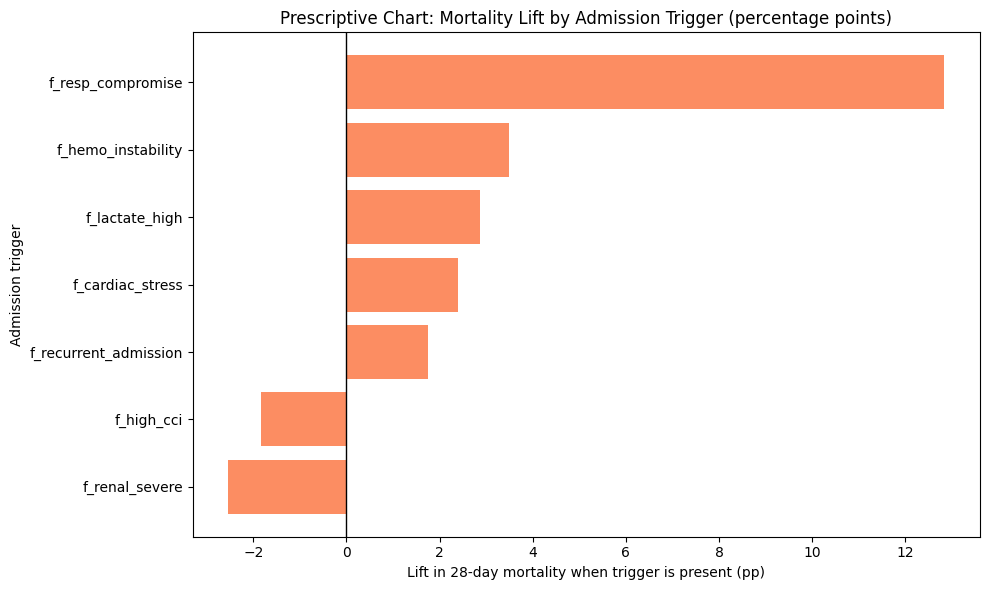

,trigger,mortality_when_present,mortality_when_absent,lift_pp
1,f_resp_compromise,13.846154,1.011715,12.834439
0,f_hemo_instability,5.194805,1.708959,3.485846
2,f_lactate_high,4.072398,1.213282,2.859116
4,f_cardiac_stress,3.823529,1.438849,2.384680
6,f_recurrent_admission,3.571429,1.818182,1.753247
5,f_high_cci,0.000000,1.843548,-1.843548
3,f_renal_severe,1.813602,4.347826,-2.534224
7,f_older_age,NaN,1.842629,NaN


In [21]:
# ...existing code...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load merged data (or reuse df if already in memory)
df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# ---------- Helpers ----------
def to_binary_outcome(s):
    if s.dtype.kind in "biufc":
        return pd.to_numeric(s, errors="coerce").fillna(0).astype(int).clip(0, 1)
    txt = s.astype("string").str.strip().str.lower()
    pos = {"1", "yes", "y", "dead", "death", "deceased", "true"}
    return txt.isin(pos).astype(int)

def col_exists(name):
    return name in df.columns

# Optional validation outcome
if col_exists("mortality_28d"):
    df["mortality_28d_bin"] = to_binary_outcome(df["mortality_28d"])
elif col_exists("death_within_28_days"):
    df["mortality_28d_bin"] = to_binary_outcome(df["death_within_28_days"])
else:
    df["mortality_28d_bin"] = np.nan

# ---------- Numeric casting ----------
num_cols = ["systolic_bp", "diastolic_bp", "pulse", "respiration", "po2", "fio2",
            "lactate", "gfr", "creatinine", "hs_troponin", "bnp", "cci_score", "visit_count"]
for c in num_cols:
    if col_exists(c):
        df[c] = pd.to_numeric(df[c], errors="coerce")

# ---------- Admission-factor triggers ----------
df["f_hemo_instability"] = (
    ((df["systolic_bp"] < 90) if col_exists("systolic_bp") else False) |
    ((df["pulse"] > 130) if col_exists("pulse") else False) |
    ((df["respiration"] > 30) if col_exists("respiration") else False)
).astype(int)

df["f_resp_compromise"] = (
    ((df["po2"] < 60) if col_exists("po2") else False) |
    ((df["fio2"] >= 40) if col_exists("fio2") else False)
).astype(int)

df["f_lactate_high"] = ((df["lactate"] >= 2.0) if col_exists("lactate") else False).astype(int)
df["f_renal_severe"] = (
    ((df["gfr"] < 30) if col_exists("gfr") else False) |
    ((df["creatinine"] >= 2.0) if col_exists("creatinine") else False)
).astype(int)

# Use dataset-relative high thresholds for markers
troponin_q90 = df["hs_troponin"].quantile(0.90) if col_exists("hs_troponin") and df["hs_troponin"].notna().any() else np.nan
bnp_q90 = df["bnp"].quantile(0.90) if col_exists("bnp") and df["bnp"].notna().any() else np.nan

df["f_cardiac_stress"] = (
    ((df["hs_troponin"] >= troponin_q90) if col_exists("hs_troponin") and pd.notna(troponin_q90) else False) |
    ((df["bnp"] >= bnp_q90) if col_exists("bnp") and pd.notna(bnp_q90) else False)
).astype(int)

df["f_high_cci"] = ((df["cci_score"] >= 6) if col_exists("cci_score") else False).astype(int)
df["f_recurrent_admission"] = ((df["visit_count"] >= 3) if col_exists("visit_count") else False).astype(int)

if col_exists("age_category"):
    age_txt = df["age_category"].astype("string").str.lower()
    df["f_older_age"] = age_txt.str.contains("70|75|80|85|90|elder|old", regex=True, na=False).astype(int)
else:
    df["f_older_age"] = 0

trigger_cols = [
    "f_hemo_instability", "f_resp_compromise", "f_lactate_high",
    "f_renal_severe", "f_cardiac_stress", "f_high_cci",
    "f_recurrent_admission", "f_older_age"
]
df["escalation_score"] = df[trigger_cols].sum(axis=1)

# Escalation rule:
# Immediate if any RED FLAG (hemo/resp/lactate) OR total score >= 3
df["icu_escalate_early"] = (
    (df["f_hemo_instability"] == 1) |
    (df["f_resp_compromise"] == 1) |
    (df["f_lactate_high"] == 1) |
    (df["escalation_score"] >= 3)
).astype(int)

# ---------- Summary ----------
summary = pd.DataFrame({
    "metric": ["Total patients", "Escalate early", "Escalation rate (%)"],
    "value": [
        len(df),
        int(df["icu_escalate_early"].sum()),
        round(100 * df["icu_escalate_early"].mean(), 2)
    ]
})
display(summary)

# Trigger prevalence among escalated patients
esc = df[df["icu_escalate_early"] == 1]
trigger_prev = (esc[trigger_cols].mean() * 100).sort_values(ascending=False).round(1)
display(trigger_prev.rename("prevalence_in_escalated_%").to_frame())


# ...existing code...

# Single clear prescriptive chart:
# "Which admission triggers are associated with higher 28-day mortality?"
if df["mortality_28d_bin"].notna().any():
    rows = []
    for t in trigger_cols:
        if t in df.columns:
            present = df.loc[df[t] == 1, "mortality_28d_bin"].mean() * 100
            absent = df.loc[df[t] == 0, "mortality_28d_bin"].mean() * 100
            lift = present - absent
            rows.append([t, present, absent, lift])

    effect = pd.DataFrame(rows, columns=["trigger", "mortality_when_present", "mortality_when_absent", "lift_pp"])
    effect = effect.sort_values("lift_pp", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(effect["trigger"], effect["lift_pp"], color="#fc8d62")
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Prescriptive Chart: Mortality Lift by Admission Trigger (percentage points)")
    plt.xlabel("Lift in 28-day mortality when trigger is present (pp)")
    plt.ylabel("Admission trigger")
    plt.tight_layout()
    plt.show()

    display(effect.sort_values("lift_pp", ascending=False))
else:
    print("28-day mortality column not available for trigger-effect chart.")

# ...existing code...


### ***16. Which patients are most likely to be readmitted within 28 days if discharged early?***

---> High comorbidity burden (cci_score high).

---> Frequent prior utilization (visit_count high).

---> Renal impairment (gfr low).

---> Residual instability at discharge window (systolic_bp low).

Readmission risk by segment (higher = more likely readmission):


,segment,rate,n
1,Mild (1),5.000000,60
0,Very Low (0),2.857143,70
2,Moderate (2),0.000000,5
3,High (3-4),0.000000,1


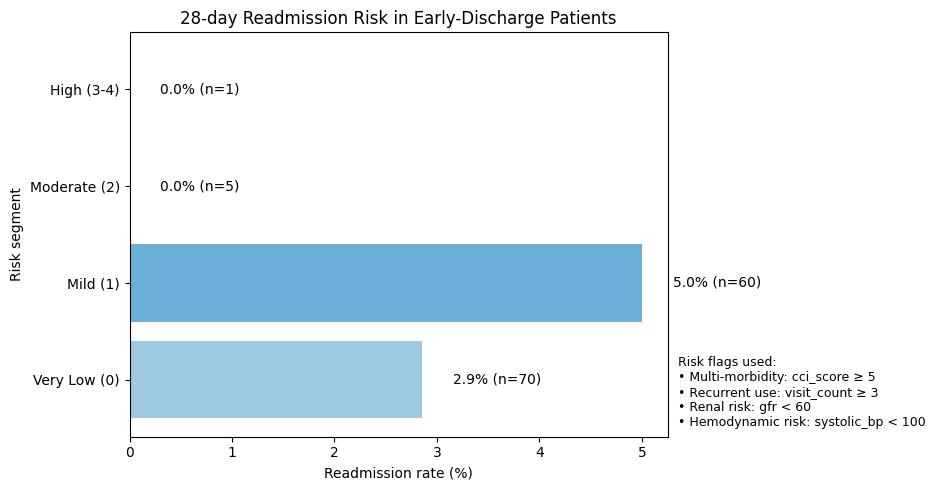

In [22]:
# Resolve column names
readmit_col = "readmission_28d" if "readmission_28d" in df.columns else "readmitted_within_28_days"
early_col = "early_discharge" if "early_discharge" in df.columns else "discharged_early"

# Derive early discharge if missing
if early_col not in df.columns:
    if "discharge_day" in df.columns:
        df["discharged_early"] = pd.to_numeric(df["discharge_day"], errors="coerce").le(3).astype(int)
        early_col = "discharged_early"
    else:
        raise ValueError("Need early-discharge column or discharge_day to derive it.")

if readmit_col not in df.columns:
    raise ValueError("Need readmission column (readmission_28d or readmitted_within_28_days).")

def to_bin(s):
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().any():
        return num.fillna(0).astype(int).clip(0, 1)
    txt = s.astype("string").str.strip().str.lower()
    return txt.isin(["1", "yes", "y", "true"]).astype(int)

# Binary outcomes
df["readmit_28d_bin"] = to_bin(df[readmit_col])
df["early_discharge_bin"] = to_bin(df[early_col])

# Early-discharge cohort
sub = df[df["early_discharge_bin"] == 1].copy()
for c in ["cci_score", "visit_count", "gfr", "systolic_bp"]:
    if c in sub.columns:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

# Risk flags
sub["risk_multi_morbidity"] = (sub["cci_score"] >= 5).astype(int) if "cci_score" in sub.columns else 0
sub["risk_recurrent_use"] = (sub["visit_count"] >= 3).astype(int) if "visit_count" in sub.columns else 0
sub["risk_renal"] = (sub["gfr"] < 60).astype(int) if "gfr" in sub.columns else 0
sub["risk_hemo"] = (sub["systolic_bp"] < 100).astype(int) if "systolic_bp" in sub.columns else 0

# Composite score + specified segments
sub["risk_score"] = sub[["risk_multi_morbidity", "risk_recurrent_use", "risk_renal", "risk_hemo"]].sum(axis=1)
segment_order = ["Very Low (0)", "Mild (1)", "Moderate (2)", "High (3-4)"]
sub["segment"] = pd.cut(sub["risk_score"], bins=[-1, 0, 1, 2, 4], labels=segment_order)

# Segment performance
seg = sub.groupby("segment", dropna=False)["readmit_28d_bin"].agg(rate="mean", n="count").reset_index()
seg["rate"] = seg["rate"] * 100
seg["segment"] = pd.Categorical(seg["segment"], categories=segment_order, ordered=True)
seg = seg.sort_values("segment")

print("Readmission risk by segment (higher = more likely readmission):")
display(seg.sort_values("rate", ascending=False))


seg_plot = seg.copy()
class segment_label_map(dict):
    def __missing__(self, key):
        return key

segment_label_map = segment_label_map({
    "Very Low (0)": "Very Low (0)",
    "Mild (1)": "Mild (1)",
    "Moderate (2)": "Moderate (2)",
    "High (3-4)": "High (3-4)"
})

seg_plot["segment_label"] = seg_plot["segment"].astype(str).map(segment_label_map)

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.barh(seg_plot["segment_label"], seg_plot["rate"], color=["#9ECAE1", "#6BAED6", "#3182BD", "#08519C"])
for i, r in seg_plot.reset_index(drop=True).iterrows():
    ax.text(r["rate"] + 0.3, i, f'{r["rate"]:.1f}% (n={int(r["n"])})', va="center")

flags_text = (
    "Risk flags used:\n"
    "• Multi-morbidity: cci_score ≥ 5\n"
    "• Recurrent use: visit_count ≥ 3\n"
    "• Renal risk: gfr < 60\n"
    "• Hemodynamic risk: systolic_bp < 100"
)
ax.text(1.02, 0.02, flags_text, transform=ax.transAxes, fontsize=9, va="bottom")

ax.set_title("28-day Readmission Risk in Early-Discharge Patients")
ax.set_xlabel("Readmission rate (%)")
ax.set_ylabel("Risk segment")
plt.tight_layout()
plt.show()

# ...existing code...

### ***16. Which patients are most likely to be readmitted within 28 days if discharged early?***
Patients who should receive a formal discharge planning bundle are those with signs of both clinical instability and higher baseline risk in your dataset. In simple terms, this includes patients with low systolic BP, poor kidney function (low GFR/high creatinine), high comorbidity burden (high CCI score), frequent prior visits, older age category, and elevated cardiac markers (troponin/BNP). These patterns indicate they are more likely to have early complications, readmission, or death after discharge, so they need structured discharge support (medication reconciliation, early follow-up, warning-sign education, and care coordination) before leaving the hospital.

Prescriptive discharge-planning overview:


,bundle_priority,patients,avg_score,readmit_rate_28d,mortality_rate_28d
0,Priority A: Full bundle + 48h call + 7d clinic,5,4.000000,0.00,0.00
1,Priority B: Full bundle + 72h call + 14d clinic,838,2.110979,8.95,3.34
2,Priority C: Standard discharge + routine follo...,1165,0.986266,5.58,0.77


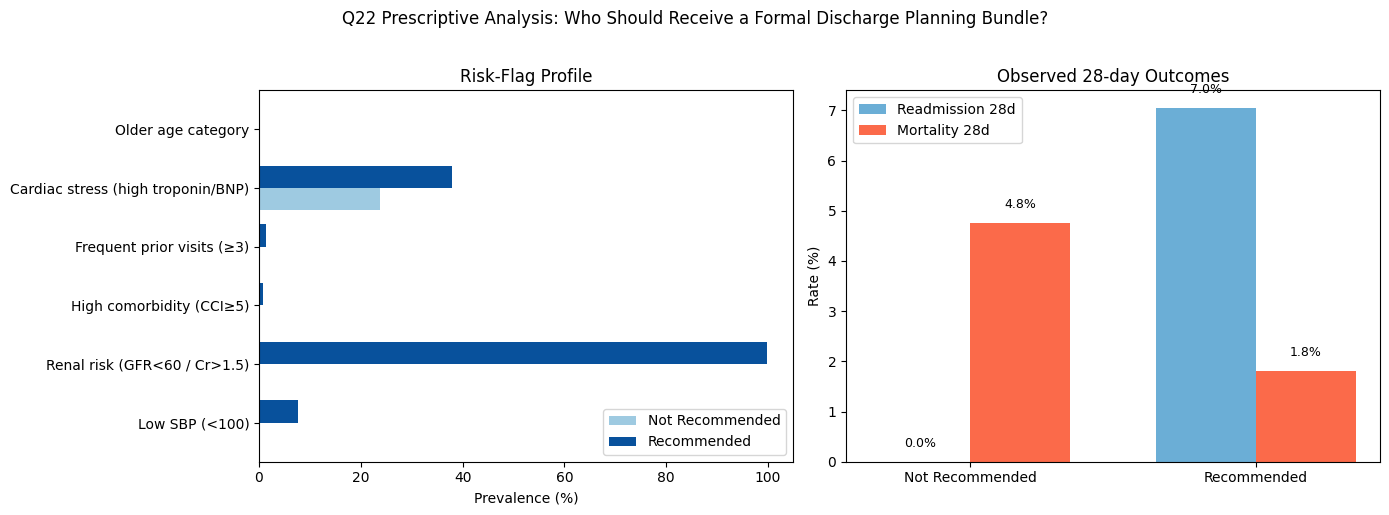

Recommended for formal discharge bundle: 99.0% of patients.


In [23]:
# ...existing code...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data if df is not already available
if "df" not in globals():
    df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# ---------- Helpers ----------
def to_bin(s):
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().any():
        return num.fillna(0).astype(int).clip(0, 1)
    txt = s.astype("string").str.strip().str.lower()
    return txt.isin(["1", "yes", "y", "true", "dead", "death", "deceased"]).astype(int)

def q75(series):
    return series.quantile(0.75) if series.notna().any() else np.nan

# ---------- Optional outcomes ----------
mort_col = "mortality_28d" if "mortality_28d" in df.columns else ("death_within_28_days" if "death_within_28_days" in df.columns else None)
readm_col = "readmission_28d" if "readmission_28d" in df.columns else ("readmitted_within_28_days" if "readmitted_within_28_days" in df.columns else None)

if mort_col:
    df["mortality_28d_bin"] = to_bin(df[mort_col])
else:
    df["mortality_28d_bin"] = np.nan

if readm_col:
    df["readmit_28d_bin"] = to_bin(df[readm_col])
else:
    df["readmit_28d_bin"] = np.nan

# ---------- Risk inputs for discharge bundle ----------
for c in ["systolic_bp", "gfr", "creatinine", "cci_score", "visit_count", "hs_troponin", "bnp"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

troponin_q75 = q75(df["hs_troponin"]) if "hs_troponin" in df.columns else np.nan
bnp_q75 = q75(df["bnp"]) if "bnp" in df.columns else np.nan

df["f_low_sbp"] = ((df["systolic_bp"] < 100) if "systolic_bp" in df.columns else False).astype(int)
df["f_renal_risk"] = (
    ((df["gfr"] < 60) if "gfr" in df.columns else False) |
    ((df["creatinine"] > 1.5) if "creatinine" in df.columns else False)
).astype(int)
df["f_high_cci"] = ((df["cci_score"] >= 5) if "cci_score" in df.columns else False).astype(int)
df["f_recurrent_use"] = ((df["visit_count"] >= 3) if "visit_count" in df.columns else False).astype(int)
df["f_cardiac_stress"] = (
    ((df["hs_troponin"] >= troponin_q75) if "hs_troponin" in df.columns and pd.notna(troponin_q75) else False) |
    ((df["bnp"] >= bnp_q75) if "bnp" in df.columns and pd.notna(bnp_q75) else False)
).astype(int)

if "age_category" in df.columns:
    age_txt = df["age_category"].astype("string").str.lower()
    df["f_older_age"] = age_txt.str.contains("70|75|80|85|90|elder|old", regex=True, na=False).astype(int)
else:
    df["f_older_age"] = 0

flag_cols = ["f_low_sbp", "f_renal_risk", "f_high_cci", "f_recurrent_use", "f_cardiac_stress", "f_older_age"]
df["bundle_risk_score"] = df[flag_cols].sum(axis=1)

# Prescriptive rule:
# formal bundle if score >=2 OR any acute instability proxy (low SBP or renal risk)
df["formal_bundle_recommended"] = (
    (df["bundle_risk_score"] >= 2) |
    (df["f_low_sbp"] == 1) |
    (df["f_renal_risk"] == 1)
).astype(int)

df["bundle_priority"] = np.select(
    [
        df["bundle_risk_score"] >= 4,
        df["bundle_risk_score"].between(2, 3),
        df["bundle_risk_score"] <= 1
    ],
    [
        "Priority A: Full bundle + 48h call + 7d clinic",
        "Priority B: Full bundle + 72h call + 14d clinic",
        "Priority C: Standard discharge + routine follow-up"
    ],
    default="Priority C: Standard discharge + routine follow-up"
)

# ---------- Overview table ----------
overview = (
    df.groupby("bundle_priority", dropna=False)
      .agg(
          patients=("bundle_priority", "count"),
          avg_score=("bundle_risk_score", "mean"),
          readmit_rate_28d=("readmit_28d_bin", "mean"),
          mortality_rate_28d=("mortality_28d_bin", "mean")
      )
      .reset_index()
)

for col in ["readmit_rate_28d", "mortality_rate_28d"]:
    if col in overview.columns:
        overview[col] = (overview[col] * 100).round(2)

priority_order = [
    "Priority A: Full bundle + 48h call + 7d clinic",
    "Priority B: Full bundle + 72h call + 14d clinic",
    "Priority C: Standard discharge + routine follow-up"
]
overview["bundle_priority"] = pd.Categorical(overview["bundle_priority"], categories=priority_order, ordered=True)
overview = overview.sort_values("bundle_priority")

print("Prescriptive discharge-planning overview:")
display(overview)

# ---------- Detailed chart ----------
flag_labels = {
    "f_low_sbp": "Low SBP (<100)",
    "f_renal_risk": "Renal risk (GFR<60 / Cr>1.5)",
    "f_high_cci": "High comorbidity (CCI≥5)",
    "f_recurrent_use": "Frequent prior visits (≥3)",
    "f_cardiac_stress": "Cardiac stress (high troponin/BNP)",
    "f_older_age": "Older age category"
}

# Flag prevalence by recommendation group
prev = (
    df.groupby("formal_bundle_recommended")[flag_cols]
      .mean()
      .T
      .reset_index()
      .rename(columns={"index": "flag", 0: "Not Recommended", 1: "Recommended"})
)
prev["flag"] = prev["flag"].map(flag_labels)
prev["Not Recommended"] = prev["Not Recommended"] * 100
prev["Recommended"] = prev["Recommended"] * 100

# Outcome rates for two groups
out = df.groupby("formal_bundle_recommended").agg(
    readmit=("readmit_28d_bin", "mean"),
    mortality=("mortality_28d_bin", "mean"),
    n=("formal_bundle_recommended", "count")
).reset_index()
out["readmit"] = out["readmit"] * 100
out["mortality"] = out["mortality"] * 100
out["group"] = out["formal_bundle_recommended"].map({0: "Not Recommended", 1: "Recommended"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: risk flag prevalence
y = np.arange(len(prev))
h = 0.38
axes[0].barh(y - h/2, prev["Not Recommended"], height=h, color="#9ecae1", label="Not Recommended")
axes[0].barh(y + h/2, prev["Recommended"], height=h, color="#08519c", label="Recommended")
axes[0].set_yticks(y)
axes[0].set_yticklabels(prev["flag"])
axes[0].set_xlabel("Prevalence (%)")
axes[0].set_title("Risk-Flag Profile")
axes[0].legend(loc="lower right")

# Right panel: outcome rates
x = np.arange(len(out))
w = 0.35
axes[1].bar(x - w/2, out["readmit"], width=w, color="#6baed6", label="Readmission 28d")
axes[1].bar(x + w/2, out["mortality"], width=w, color="#fb6a4a", label="Mortality 28d")
axes[1].set_xticks(x)
axes[1].set_xticklabels(out["group"])
axes[1].set_ylabel("Rate (%)")
axes[1].set_title("Observed 28-day Outcomes")
axes[1].legend()

for i, r in out.iterrows():
    axes[1].text(i - w/2, r["readmit"] + 0.3, f'{r["readmit"]:.1f}%', ha="center", fontsize=9)
    axes[1].text(i + w/2, r["mortality"] + 0.3, f'{r["mortality"]:.1f}%', ha="center", fontsize=9)

plt.suptitle("Q22 Prescriptive Analysis: Who Should Receive a Formal Discharge Planning Bundle?", y=1.02)
plt.tight_layout()
plt.show()

# Quick headline metric
bundle_rate = 100 * df["formal_bundle_recommended"].mean()
print(f"Recommended for formal discharge bundle: {bundle_rate:.1f}% of patients.")
# ...existing code...

### ***17. Which patients need a home-based follow-up plan instead of routine discharge?***

Patients who need a home-based follow-up plan instead of routine discharge are those with the highest post-discharge risk profile in your dataset: low systolic_bp, renal dysfunction (gfr < 60 or high creatinine), high comorbidity burden (cci_score high), frequent prior admissions (visit_count >= 3), older age category, and elevated cardiac markers (hs_troponin/bnp). These patients are more likely to deteriorate, be readmitted, or die within 28 days, so routine discharge is usually insufficient. A home-based plan is more appropriate because it adds close monitoring, early symptom detection, medication support, and faster escalation if condition worsens

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def to_bin(s: pd.Series) -> pd.Series:
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().any():
        return num.fillna(0).astype(int).clip(0, 1)
    txt = s.astype("string").str.strip().str.lower()
    return txt.isin(["1", "yes", "y", "true", "dead", "death", "deceased"]).astype(int)


def q75(series: pd.Series) -> float:
    return series.quantile(0.75) if series.notna().any() else np.nan


def build_home_followup_prescriptive(df: pd.DataFrame):
    df = df.copy()

    # Optional outcomes
    mort_col = "mortality_28d" if "mortality_28d" in df.columns else ("death_within_28_days" if "death_within_28_days" in df.columns else None)
    readm_col = "readmission_28d" if "readmission_28d" in df.columns else ("readmitted_within_28_days" if "readmitted_within_28_days" in df.columns else None)

    df["mortality_28d_bin"] = to_bin(df[mort_col]) if mort_col else np.nan
    df["readmit_28d_bin"] = to_bin(df[readm_col]) if readm_col else np.nan

    # Numeric casting
    for c in ["systolic_bp", "gfr", "creatinine", "cci_score", "visit_count", "hs_troponin", "bnp"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Dynamic thresholds
    troponin_q75 = q75(df["hs_troponin"]) if "hs_troponin" in df.columns else np.nan
    bnp_q75 = q75(df["bnp"]) if "bnp" in df.columns else np.nan

    # Risk flags
    df["f_low_sbp"] = ((df["systolic_bp"] < 100) if "systolic_bp" in df.columns else False).astype(int)
    df["f_renal_risk"] = (
        ((df["gfr"] < 60) if "gfr" in df.columns else False) |
        ((df["creatinine"] > 1.5) if "creatinine" in df.columns else False)
    ).astype(int)
    df["f_high_cci"] = ((df["cci_score"] >= 5) if "cci_score" in df.columns else False).astype(int)
    df["f_recurrent_use"] = ((df["visit_count"] >= 3) if "visit_count" in df.columns else False).astype(int)
    df["f_cardiac_stress"] = (
        ((df["hs_troponin"] >= troponin_q75) if "hs_troponin" in df.columns and pd.notna(troponin_q75) else False) |
        ((df["bnp"] >= bnp_q75) if "bnp" in df.columns and pd.notna(bnp_q75) else False)
    ).astype(int)

    if "age_category" in df.columns:
        age_txt = df["age_category"].astype("string").str.lower()
        df["f_older_age"] = age_txt.str.contains("70|75|80|85|90|elder|old", regex=True, na=False).astype(int)
    else:
        df["f_older_age"] = 0

    flag_cols = ["f_low_sbp", "f_renal_risk", "f_high_cci", "f_recurrent_use", "f_cardiac_stress", "f_older_age"]
    df["home_risk_score"] = df[flag_cols].sum(axis=1)

    # Prescriptive recommendation
    df["home_followup_recommended"] = (
        (df["home_risk_score"] >= 3) |
        ((df["f_low_sbp"] == 1) & (df["f_renal_risk"] == 1)) |
        ((df["home_risk_score"] >= 2) & (df["f_older_age"] == 1))
    ).astype(int)

    # Priority tiers
    df["home_priority"] = np.select(
        [
            df["home_risk_score"] >= 4,
            df["home_risk_score"].between(2, 3),
            df["home_risk_score"] <= 1
        ],
        [
            "Priority A: Intensive home follow-up (24-48h call + 7d home/clinic review)",
            "Priority B: Moderate home follow-up (72h call + 14d review)",
            "Priority C: Routine discharge follow-up"
        ],
        default="Priority C: Routine discharge follow-up"
    )

    # Overview table
    overview = (
        df.groupby("home_priority", dropna=False)
          .agg(
              patients=("home_priority", "count"),
              avg_score=("home_risk_score", "mean"),
              readmit_rate_28d=("readmit_28d_bin", "mean"),
              mortality_rate_28d=("mortality_28d_bin", "mean")
          )
          .reset_index()
    )

    for col in ["readmit_rate_28d", "mortality_rate_28d"]:
        if col in overview.columns:
            overview[col] = (overview[col] * 100).round(2)

    priority_order = [
        "Priority A: Intensive home follow-up (24-48h call + 7d home/clinic review)",
        "Priority B: Moderate home follow-up (72h call + 14d review)",
        "Priority C: Routine discharge follow-up"
    ]
    overview["home_priority"] = pd.Categorical(overview["home_priority"], categories=priority_order, ordered=True)
    overview = overview.sort_values("home_priority")

    return df, overview, flag_cols


def plot_home_followup_detailed(df: pd.DataFrame, flag_cols):
    flag_labels = {
        "f_low_sbp": "Low SBP (<100)",
        "f_renal_risk": "Renal risk (GFR<60 / Cr>1.5)",
        "f_high_cci": "High comorbidity (CCI≥5)",
        "f_recurrent_use": "Frequent prior visits (≥3)",
        "f_cardiac_stress": "Cardiac stress (high troponin/BNP)",
        "f_older_age": "Older age category"
    }

    prev = (
        df.groupby("home_followup_recommended")[flag_cols]
          .mean()
          .T
          .reset_index()
          .rename(columns={"index": "flag", 0: "Not Recommended", 1: "Recommended"})
    )
    prev["flag"] = prev["flag"].map(flag_labels)
    prev["Not Recommended"] = prev["Not Recommended"] * 100
    prev["Recommended"] = prev["Recommended"] * 100

    out = df.groupby("home_followup_recommended").agg(
        readmit=("readmit_28d_bin", "mean"),
        mortality=("mortality_28d_bin", "mean"),
        n=("home_followup_recommended", "count")
    ).reset_index()
    out["readmit"] = out["readmit"] * 100
    out["mortality"] = out["mortality"] * 100
    out["group"] = out["home_followup_recommended"].map({0: "Not Recommended", 1: "Recommended"})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    y = np.arange(len(prev))
    h = 0.38
    axes[0].barh(y - h / 2, prev["Not Recommended"], height=h, color="#b3cde3", label="Not Recommended")
    axes[0].barh(y + h / 2, prev["Recommended"], height=h, color="#005b96", label="Recommended")
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(prev["flag"])
    axes[0].set_xlabel("Prevalence (%)")
    axes[0].set_title("Risk-Flag Profile")
    axes[0].legend(loc="lower right")

    x = np.arange(len(out))
    w = 0.35
    axes[1].bar(x - w / 2, out["readmit"], width=w, color="#6baed6", label="Readmission 28d")
    axes[1].bar(x + w / 2, out["mortality"], width=w, color="#fb6a4a", label="Mortality 28d")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(out["group"])
    axes[1].set_ylabel("Rate (%)")
    axes[1].set_title("Observed 28-day Outcomes")
    axes[1].legend()

    for i, r in out.iterrows():
        axes[1].text(i - w / 2, r["readmit"] + 0.3, f"{r['readmit']:.1f}%", ha="center", fontsize=9)
        axes[1].text(i + w / 2, r["mortality"] + 0.3, f"{r['mortality']:.1f}%", ha="center", fontsize=9)

    plt.suptitle("Q23 Prescriptive Analysis: Who Needs Home-Based Follow-up Instead of Routine Discharge?", y=1.03)
    plt.tight_layout()
    plt.show()


def run_home_followup_analysis(csv_path="cleaned_files/heart_failure_merged.csv"):
    df = pd.read_csv(csv_path)
    scored_df, overview, flag_cols = build_home_followup_prescriptive(df)
    print("Prescriptive home-follow-up overview:")
    print(overview)
    plot_home_followup_detailed(scored_df, flag_cols)
    rate = 100 * scored_df["home_followup_recommended"].mean()
    print(f"Recommended for home-based follow-up: {rate:.1f}% of patients.")
    return scored_df, overview


   

## ***Q. bnp vs readmission/mortality correlation.***
##### *Reasoning:BNP is a biomarker of cardiac wall stress and HF severity. Patients with higher BNP are expected to have more advanced heart failure and worse short-term outcomes.If BNP rises across the categories from Low to High, the analysis supports using BNP as a risk marker for readmission and mortality.- Stronger positive association with poor outcome suggests that BNP should be considered in discharge planning and follow-up prioritization.*


Outcome rates by BNP category (%)
            bnp_group  readmission_28d  readmission_3mo  readmission_6mo  \
0          Low (<100)             8.24            24.73            40.11   
1  Moderate (100-400)             6.54            23.84            38.61   
2         High (>400)             6.95            25.15            38.24   

   mortality_28d  death_3mo  poor_outcome  
0           1.65       1.65         41.76  
1           0.63       0.84         39.66  
2           2.29       2.59         40.98  


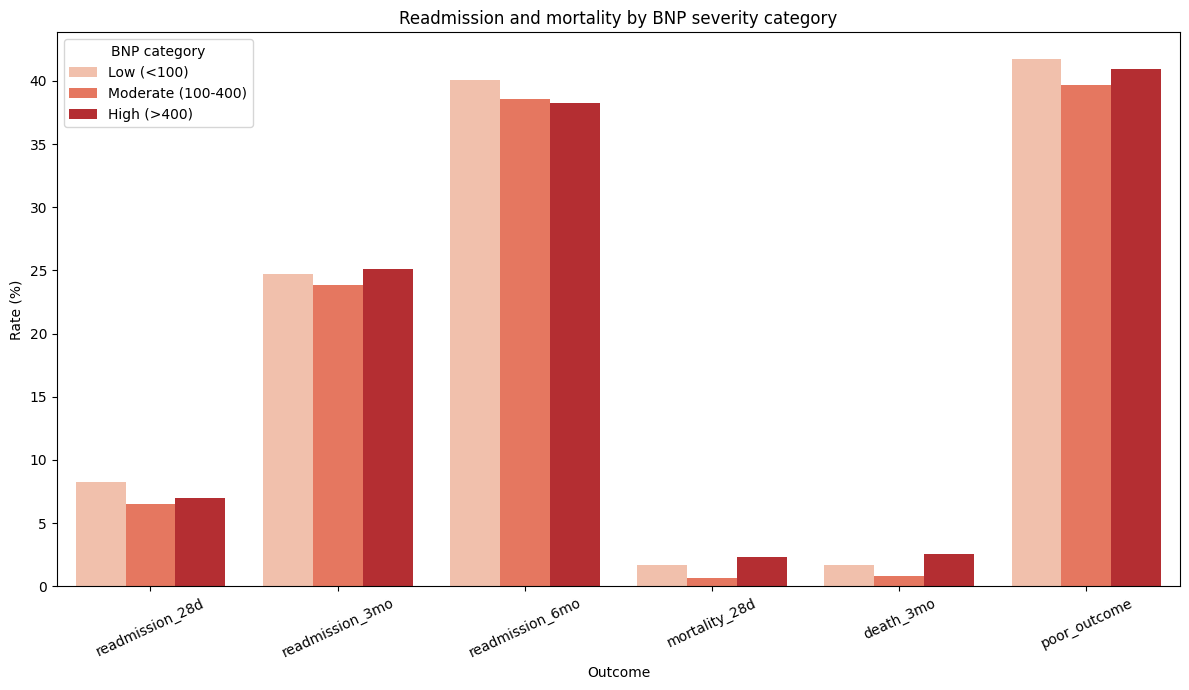

/Users/are/Development/DA229/PythonHackathon/Team3_PyCoders_PythonHackathon_SEP2026/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/are/Development/DA229/PythonHackathon/Team3_PyCoders_PythonHackathon_SEP2026/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/are/Development/DA229/PythonHackathon/Team3_PyCoders_PythonHackathon_SEP2026/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


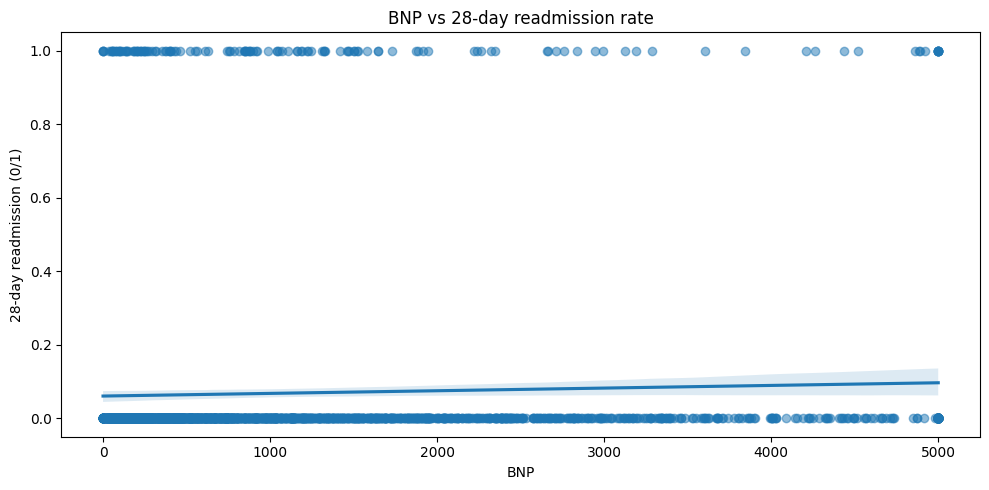

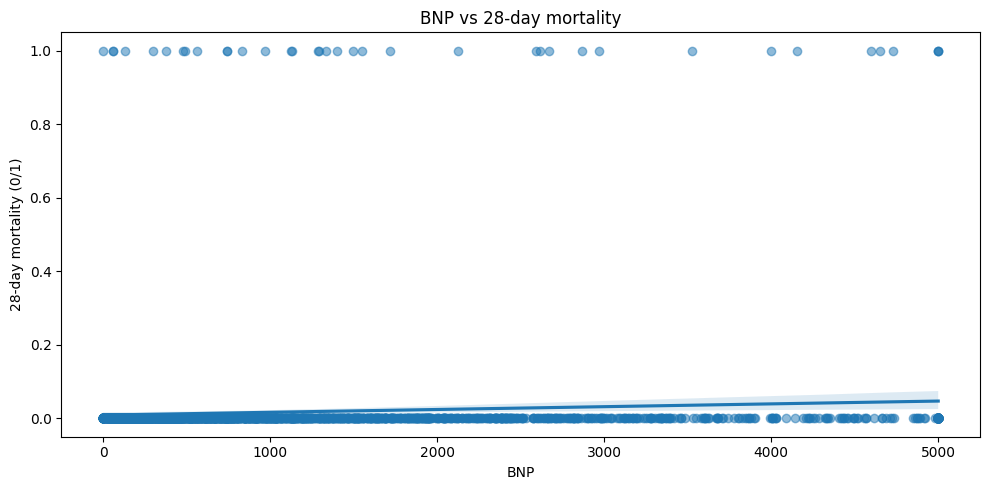


Correlation of BNP with outcomes:
                   bnp  readmission_28d  mortality_28d
bnp              1.000            0.038          0.077
readmission_28d  0.038            1.000         -0.038
mortality_28d    0.077           -0.038          1.000

Clinical reasoning:
- BNP is a biomarker of cardiac wall stress and HF severity.
- Patients with higher BNP are expected to have more advanced heart failure and worse short-term outcomes.
- If BNP rises across the categories from Low to High, the analysis supports using BNP as a risk marker for readmission and mortality.
- Stronger positive association with poor outcome suggests that BNP should be considered in discharge planning and follow-up prioritization.



In [25]:
# -----------------------------
# 1. Clean key variables
# -----------------------------
for col in [
    "bnp", "readmission_28d", "readmission_3mo", "readmission_6mo",
    "mortality_28d", "death_3mo"
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Create a combined adverse outcome flag
df["poor_outcome"] = df[[
    "readmission_28d", "readmission_3mo", "readmission_6mo",
    "mortality_28d", "death_3mo"
]].max(axis=1)

# -----------------------------
# 2. BNP severity categories
# -----------------------------
# Clinically meaningful bins:
# <100 = low/normal
# 100-400 = moderate elevation
# >400 = high elevation
df["bnp_group"] = pd.cut(
    df["bnp"],
    bins=[-1, 100, 400, np.inf],
    labels=["Low (<100)", "Moderate (100-400)", "High (>400)"],
    right=True
)

# -----------------------------
# 3. Summarize outcomes by BNP category
# -----------------------------
outcome_cols = [
    "readmission_28d", "readmission_3mo", "readmission_6mo",
    "mortality_28d", "death_3mo", "poor_outcome"
]

summary = (
    df.groupby("bnp_group")[outcome_cols]
      .mean()
      .mul(100)
      .round(2)
      .reset_index()
)

print("Outcome rates by BNP category (%)")
print(summary)

# -----------------------------
# 4. Plot: BNP category vs outcomes
# -----------------------------
plot_df = summary.melt(
    id_vars="bnp_group",
    value_vars=["readmission_28d", "readmission_3mo", "readmission_6mo",
                "mortality_28d", "death_3mo", "poor_outcome"],
    var_name="Outcome",
    value_name="Rate_percent"
)

plt.figure(figsize=(12, 7))
sns.barplot(data=plot_df, x="Outcome", y="Rate_percent", hue="bnp_group", palette="Reds")
plt.title("Readmission and mortality by BNP severity category")
plt.xlabel("Outcome")
plt.ylabel("Rate (%)")
plt.xticks(rotation=25)
plt.legend(title="BNP category")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Continuous BNP vs 28-day readmission
# -----------------------------
# Only use rows with some variation in BNP
scatter_df = df[["bnp", "readmission_28d", "mortality_28d"]].dropna()

plt.figure(figsize=(10, 5))
sns.regplot(data=scatter_df, x="bnp", y="readmission_28d", scatter_kws={"alpha": 0.5})
plt.title("BNP vs 28-day readmission rate")
plt.xlabel("BNP")
plt.ylabel("28-day readmission (0/1)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.regplot(data=scatter_df, x="bnp", y="mortality_28d", scatter_kws={"alpha": 0.5})
plt.title("BNP vs 28-day mortality")
plt.xlabel("BNP")
plt.ylabel("28-day mortality (0/1)")
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Correlation summary
# -----------------------------
corr_df = scatter_df[["bnp", "readmission_28d", "mortality_28d"]].corr().round(3)
print("\nCorrelation of BNP with outcomes:")
print(corr_df)

# -----------------------------
# 7. Reasoning text
# -----------------------------
print("""
Clinical reasoning:
- BNP is a biomarker of cardiac wall stress and HF severity.
- Patients with higher BNP are expected to have more advanced heart failure and worse short-term outcomes.
- If BNP rises across the categories from Low to High, the analysis supports using BNP as a risk marker for readmission and mortality.
- Stronger positive association with poor outcome suggests that BNP should be considered in discharge planning and follow-up prioritization.
""")

### ***Q17. Which recorded drug groups are most common among readmitted patients, and should their documentation or medication reconciliation process be reviewed?***

***Reasoning:***
<i>The key idea is:
identify whether a patient was ever readmitted
split the medication list into clinically meaningful groups
compare which groups appear repeatedly among readmitted patients
look for groups with both high frequency and high readmission prevalence
This is descriptive and prescriptive because it points to operational issues such as

- incomplete discharge medication reconciliation
- unclear home medication instructions
- duplicate or conflicting therapy
- poor medication continuity after discharge

A group that is common in readmitted patients may not be the cause of readmission, but it is a strong candidate for process review.<i>

             drug_group  patients  readmission_rate
5             Diuretics       767               1.0
4   Digoxin / Inotropes       705               1.0
2         Antiplatelets       454               1.0
7               Statins       318               1.0
3         Beta-blockers       304               1.0
0               ACE/ARB       301               1.0
8          Vasodilators       178               1.0
1        Anticoagulants       167               1.0
6  Other / Unclassified         1               1.0


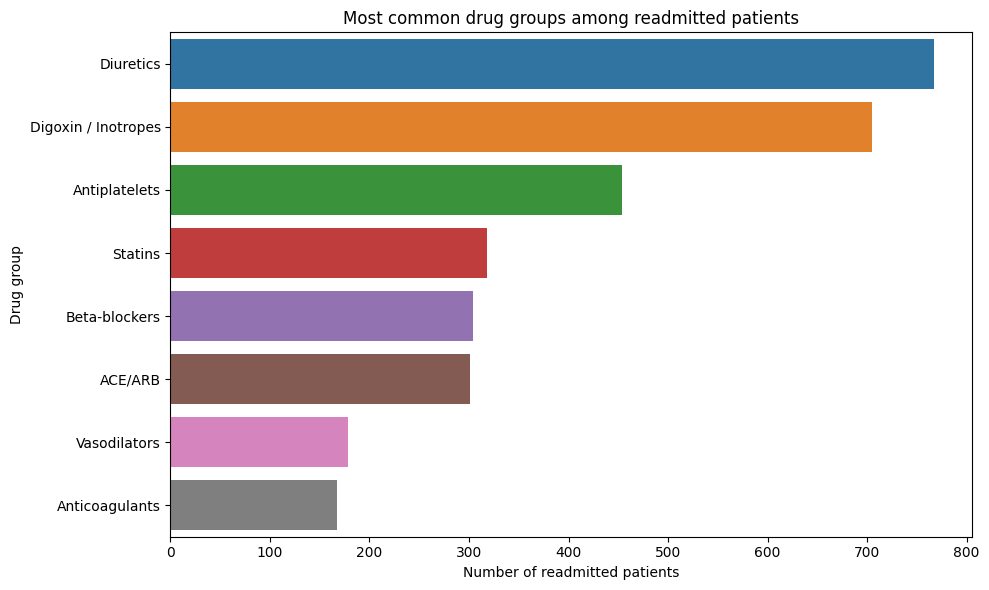

In [26]:

# Create an overall readmission flag
med_df = hf_df.copy()
readmission_cols = ["readmission_28d", "readmission_3mo", "readmission_6mo"]
med_df["readmission_any"] = (
    med_df[readmission_cols]
    .fillna(0)
    .astype(int)
    .max(axis=1)
)

# Clean medication field
med_df["drugs_list"] = med_df["drugs_list"].fillna("").astype(str).str.lower().str.strip()

# Drug group mapping (broad clinical grouping)
drug_patterns = {
    "Diuretics": ["furosemide", "torasemide", "hydrochlorothiazide", "bumetanide", "spironolactone"],
    "Beta-blockers": ["metoprolol", "carvedilol", "bisoprolol", "atenolol"],
    "ACE/ARB": ["benazepril", "lisinopril", "valsartan", "losartan", "candesartan", "irbesartan"],
    "Anticoagulants": ["enoxaparin", "warfarin", "heparin", "rivaroxaban", "apixaban", "dabigatran"],
    "Antiplatelets": ["aspirin", "clopidogrel", "ticagrelor"],
    "Statins": ["atorvastatin", "rosuvastatin", "simvastatin", "pravastatin"],
    "Digoxin / Inotropes": ["digoxin", "milrinone", "deslanoside", "adenosine"],
    "Vasodilators": ["nitroglycerin", "isosorbide", "nicorandil"],
    "Other / Unclassified": []
}

def assign_drug_groups(drug_text):
    text = str(drug_text).lower()
    groups = []
    for group, terms in drug_patterns.items():
        if group == "Other / Unclassified":
            continue
        if any(term in text for term in terms):
            groups.append(group)
    return groups if groups else ["Other / Unclassified"]

med_df["drug_groups"] = med_df["drugs_list"].apply(assign_drug_groups)

# Keep only readmitted patients for this question
readmitted = med_df[med_df["readmission_any"] == 1].copy()

# Expand drug groups for counting
group_summary = (
    readmitted.explode("drug_groups")
    .groupby("drug_groups")
    .agg(
        patients=("patient_id", "count"),
        readmission_rate=("readmission_any", "mean")
    )
    .reset_index()
    .rename(columns={"drug_groups": "drug_group"})
    .sort_values(["patients", "readmission_rate"], ascending=[False, False])
)

print(group_summary.head(10))

# Most common drug groups among readmitted patients
top = group_summary.head(8).copy()
top["readmission_rate_pct"] = top["readmission_rate"] * 100

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top,
    x="patients",
    y="drug_group",
    hue="drug_group",
    dodge=False,
    legend=False
)

plt.title("Most common drug groups among readmitted patients")
plt.xlabel("Number of readmitted patients")
plt.ylabel("Drug group")
plt.tight_layout()
plt.show()

**Key Insights:**
<i>- Diuretics are the most common medication group among readmitted patients.
- This is not because they are proven to cause readmission, but because they are the most frequently recorded drug class in that readmitted group.
- The chart suggests that heart-failure medication burden is very high in the readmitted cohort, especially for drugs used in symptom control and volume management.<i>

**Practical interpretation**
<i>
- Diuretics are heavily represented in readmitted patients, which makes them a strong candidate for medication reconciliation review.
- A high frequency of these drugs may reflect:
    - complex heart-failure management
    - frequent changes in home medications
    - incomplete discharge instructions
    - poor follow-up adherence
    - need for clearer documentation at discharge

<div style="font-family: Cambria; font-size: 16px; color: green;">

Diuretics are the most frequently recorded drug group among readmitted heart failure patients, followed by other standard HF therapies such as beta-blockers, ACE/ARB medications, anticoagulants, and antiplatelets. This pattern suggests that readmitted patients are often on a complex medication regimen, particularly for symptom control and cardiovascular risk management. While the chart does not establish causality, the repeated presence of diuretics and related HF therapies in the readmitted cohort highlights a potential medication-related service issue. In a prescriptive context, this supports a review of discharge medication reconciliation, patient education, and documentation accuracy, particularly for high-risk heart failure medications. Strengthening reconciliation processes at admission and discharge, clarifying home medication instructions, and improving continuity of follow-up may help reduce medication-related contributors to readmission and improve care transitions for these patients.
</div>
<i>

### ***Q18. Does the number of distinct recorded drugs per patient relate to readmission, suggesting a group for a medication reconciliation review?***

<i>**Reasoning:**
1) Why we compared distinct drug count by readmission status
The variable we are examining is not just the presence of a drug, but the number of unique drugs recorded for each patient. This matters because patients with more complex medication regimens often have:

    - more comorbidities
    - more prescriptions
    - more risk of drug interactions
    - higher risk of non-adherence or prescribing errors

So the logic is: if readmitted patients tend to have a higher count of distinct medications, that may suggest a medication burden issue and support a medication reconciliation review.<i>

   readmission_any  avg_distinct_drugs  median_distinct_drugs  patients  \
0                0            7.483766                    8.0      1232   
1                1            7.925161                    8.0       775   

  readmission_label  
0    Not readmitted  
1        Readmitted  


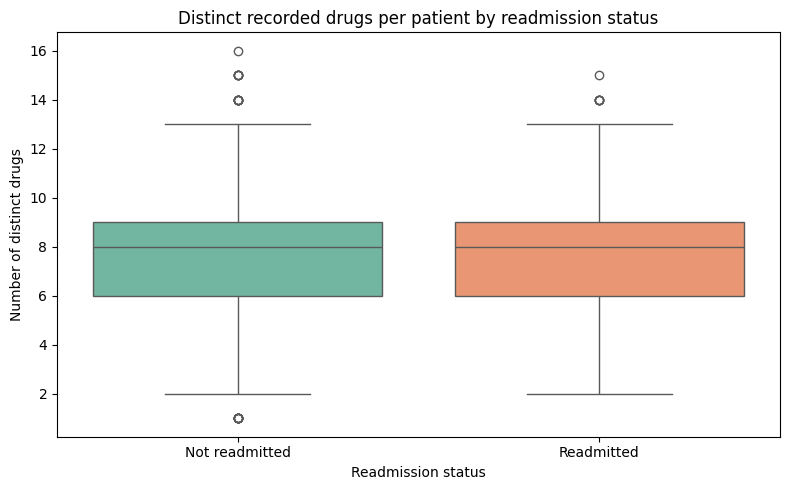

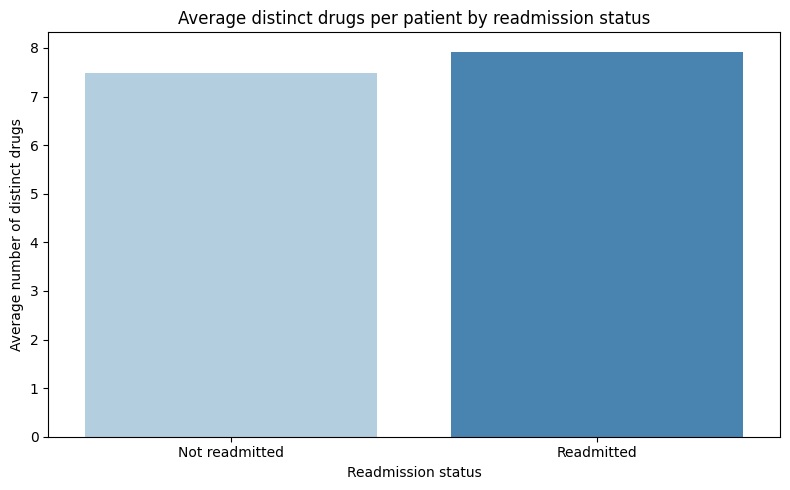

In [27]:
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")
# Create a binary readmission flag
readmission_cols = ["readmission_28d", "readmission_3mo", "readmission_6mo"]
hf_df["readmission_any"] = (
    hf_df[readmission_cols]
    .fillna(0)
    .astype(int)
    .max(axis=1)
)

# Clean drug list
hf_df["drugs_list"] = hf_df["drugs_list"].fillna("").astype(str).str.strip()

# Expand comma-separated medication names
drug_long = (
    hf_df[["patient_id", "drugs_list"]]
    .dropna(subset=["drugs_list"])
    .copy()
)

drug_long["drug_name_list"] = drug_long["drugs_list"].str.split(",")
drug_long = drug_long.explode("drug_name_list")

drug_long["drug_name_list"] = drug_long["drug_name_list"].str.strip().str.lower()
drug_long = drug_long[drug_long["drug_name_list"] != ""]

# Count the number of unique recorded drugs per patient
distinct_drugs_per_patient = (
    drug_long
    .drop_duplicates()
    .groupby("patient_id")["drug_name_list"]
    .nunique()
    .reset_index()
    .rename(columns={"drug_name_list": "distinct_drugs"})
)

# Merge with readmission flag
analysis_df = distinct_drugs_per_patient.merge(
    hf_df[["patient_id", "readmission_any"]].drop_duplicates(),
    on="patient_id",
    how="left"
)

# Summary statistics by readmission status
summary = (
    analysis_df.groupby("readmission_any")
    .agg(
        avg_distinct_drugs=("distinct_drugs", "mean"),
        median_distinct_drugs=("distinct_drugs", "median"),
        patients=("patient_id", "count")
    )
    .reset_index()
)

summary["readmission_label"] = summary["readmission_any"].map({
    0: "Not readmitted",
    1: "Readmitted"
})

print(summary)

# Boxplot: distinct drugs by readmission status
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=analysis_df,
    x="readmission_any",
    y="distinct_drugs",
    hue="readmission_any",
    palette="Set2",
    legend=False
)

plt.xticks([0, 1], ["Not readmitted", "Readmitted"])
plt.title("Distinct recorded drugs per patient by readmission status")
plt.xlabel("Readmission status")
plt.ylabel("Number of distinct drugs")
plt.tight_layout()
plt.show()

# Bar chart: average distinct drugs per patient
plt.figure(figsize=(8, 5))
sns.barplot(
    data=summary,
    x="readmission_label",
    y="avg_distinct_drugs",
    hue="readmission_label",
    palette="Blues",
    legend=False
)

plt.title("Average distinct drugs per patient by readmission status")
plt.xlabel("Readmission status")
plt.ylabel("Average number of distinct drugs")
plt.tight_layout()
plt.show()

<i>**Key insights from the charts**
<div style="font-family: Cambria; font-size: 16px; color: green;">

<strong>1) Boxplot insight</strong>

The box plot shows:

<ul>
<li>median is around 8 for both groups</li>
<li>interquartile ranges are very similar</li>
<li>the readmitted group is only slightly shifted upward</li>
<li>there are outliers in both groups, but they do not create a strong separation</li>
</ul>

This suggests that medication burden is not dramatically different between readmitted and non-readmitted patients.

<strong>2) Bar chart insight</strong>

The average-drug bar chart confirms the same pattern:

<ul>
<li>not readmitted ≈ 7.5 drugs</li>
<li>readmitted ≈ 7.9 drugs</li>
</ul>

The difference is small, and visually it is almost flat. This means the count of distinct drugs is not a strong standalone marker of readmission risk.

<strong>The number of distinct recorded drugs per patient does not appear to be a strong predictor of readmission in this dataset.</strong> Although the readmitted group has a slightly higher average medication count, the difference is modest and the distributions overlap substantially. Therefore, while polypharmacy may still matter clinically, it should not be treated as a standalone trigger for medication reconciliation review based on this chart alone.

</div>


### ***Q19. Which patient groups could be used for a small follow-up pilot, based on high readmission rates and a sufficient number of patients?***

<i>**Reasoning:**
The best pilot target is not simply the group with the highest readmission rate, but the group that has both a high readmission rate and enough patients to make a small pilot feasible and statistically meaningful. That is why the right method is to segment the dataset by clinically meaningful groups such as:

- NYHA class
- Killip grade
- age group
- diabetes / hypertension / smoking status
- combinations such as “older + high NYHA class”

A good pilot group should combine elevated risk of readmission, enough sample size to recruit and follow for a small intervention, operational practicality for a focused discharge or medication review program

The strongest pilot candidates are often older adults with NYHA III/IV or Killip III/IV, patients with both high severity and comorbidity burden, groups with readmission rates meaningfully above the overall average and at least 50–100 patients.

That gives you a realistic pilot population, rather than a tiny high-risk subgroup with too few people to support intervention testing.<i>


  age_group   high_severity  patients  readmission_rate
7    89-110  Lower severity       101          0.415842
5     69-79  Lower severity       715          0.412587
6     79-89  Lower severity       646          0.380805
3     49-59  Lower severity       106          0.377358
4     59-69  Lower severity       368          0.355978
2     39-49  Lower severity        56          0.321429


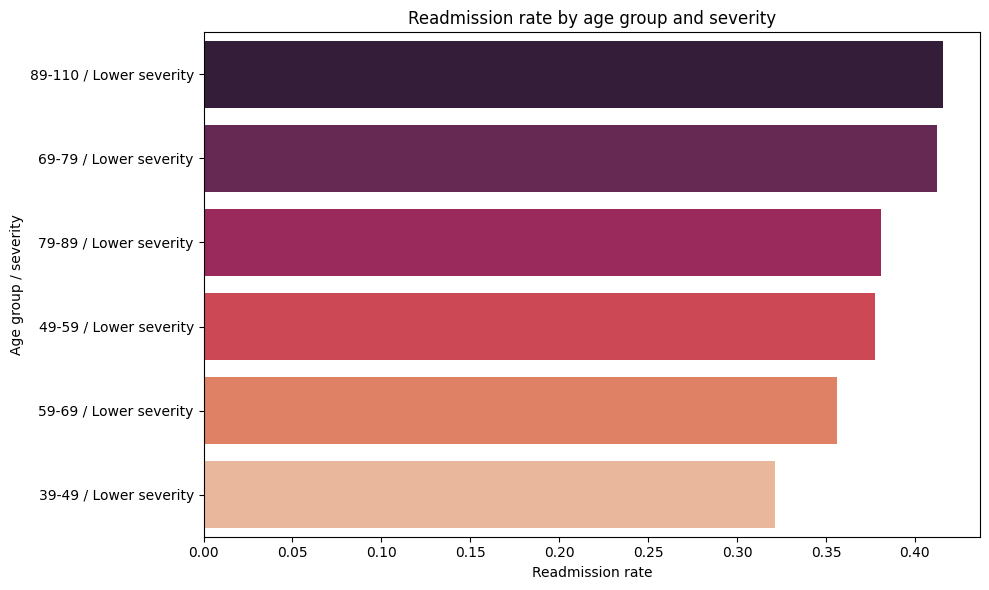

In [28]:
# Reload the merged dataset to avoid stale column issues
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")
hf_df.columns = hf_df.columns.str.strip()

# Create readmission marker
readmission_cols = ["readmission_28d", "readmission_3mo", "readmission_6mo"]
hf_df["readmission_any"] = (
    hf_df[readmission_cols]
    .fillna(0)
    .astype(int)
    .max(axis=1)
)

# Use the age column that actually exists in the merged file
hf_df["age_group"] = hf_df["age_category"].fillna("Unknown")

# Use the actual NYHA column and a safe fallback
nyha_col = "nyha_cardiac_function_classification"
if nyha_col not in hf_df.columns:
    nyha_col = [c for c in hf_df.columns if "nyha" in c.lower()][0]

# Create severity flag
hf_df["high_severity"] = np.where(
    hf_df[nyha_col].astype(str).str.strip().isin(["III", "IV"]) |
    hf_df["killip_grade"].astype(str).str.strip().isin(["III", "IV"]),
    "High severity",
    "Lower severity"
)

# Example grouping for the pilot question
pilot_df = (
    hf_df.groupby(["age_group", "high_severity"], dropna=False)
    .agg(
        patients=("patient_id", "count"),
        readmission_rate=("readmission_any", "mean")
    )
    .reset_index()
)

pilot_df = pilot_df[pilot_df["patients"] >= 50].sort_values(
    ["readmission_rate", "patients"],
    ascending=[False, False]
)

print(pilot_df.head(10))

plot_df = pilot_df.head(8)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="readmission_rate",
    y=plot_df["age_group"].astype(str) + " / " + plot_df["high_severity"].astype(str),
    hue=plot_df["age_group"].astype(str) + " / " + plot_df["high_severity"].astype(str),
    palette="rocket",
    dodge=False
)
plt.title("Readmission rate by age group and severity")
plt.xlabel("Readmission rate")
plt.ylabel("Age group / severity")
plt.tight_layout()
plt.show()

<i>**Key insights**

<div style="font-family: Cambria; font-size: 16px; color: green;">

This chart is comparing readmission rate across age groups, and it shows that the strongest pilot candidates are older adults with sufficiently large sample sizes.

<strong>1) Older age groups have the highest readmission rates</strong>

The highest readmission rate is in the 89–110 age group at:

<strong>41.6%</strong>

Other older groups are also very high:

<ul>
<li>69–79: 41.3%</li>
<li>79–89: 38.1%</li>
<li>49–59: 37.7%</li>
<li>59–69: 35.6%</li>
<li>39–49: 32.1%</li>
</ul>

This suggests that age is a very important factor in the risk profile.

<strong>2) All the eligible groups shown are “Lower severity”</strong>

The chart only includes lower-severity groups because those were the ones meeting the minimum patient threshold for the pilot selection.

This is important because it tells us:

<ul>
<li>the dataset is dominated by a large lower-severity population</li>
<li>older age alone may be driving readmission risk more than severity in this pilot subset</li>
<li>there may not be enough high-severity cases in the sample to form a strong intervention group</li>
</ul>

<strong>3) The strongest pilot groups are statistically feasible</strong>

The sample sizes are large enough for a small follow-up pilot:

<ul>
<li>89–110: 101 patients</li>
<li>69–79: 715 patients</li>
<li>79–89: 646 patients</li>
<li>49–59: 106 patients</li>
<li>59–69: 368 patients</li>
<li>39–49: 56 patients</li>
</ul>

This matters because a pilot should be high risk, operationally manageable, and large enough to support follow-up and evaluation.

<strong>4) Best pilot target</strong>

The most practical pilot group is likely age 69–79 or 79–89, lower severity.

<strong>Why?</strong>

<ul>
<li>high readmission rate</li>
<li>large patient count</li>
<li>enough volume to run a focused follow-up intervention</li>
</ul>

</div>


### ***Q20. After a follow-up pilot is introduced, what measures should be tracked to evaluate it: 28-day readmission, 6-month emergency visits, length of stay, or another outcome?***

<i>**Reasoning:**
For a follow-up pilot in heart failure care, the best measures are the ones that are:

- directly linked to patient outcomes
- sensitive to discharge and follow-up processes
- actionable for a small intervention
- available in the merged dataset

The strongest choices are:

1. **28-day readmission**: This is the most immediate and clinically meaningful signal after discharge. It reflects whether discharge planning, medication reconciliation, and follow-up are working.
2. **6-month emergency department return**: This captures recurrence of instability beyond the first month.It is useful for seeing whether the pilot reduces avoidable urgent re-contact.
3. **Length of stay**: This is useful as a secondary operational measure. It helps understand whether the intervention influences hospital burden, but it is not the best primary success measure because it can be affected by illness severity.
4. **28-day mortality**: Important clinically, but usually a lower-frequency outcome. For a small pilot, it may be too rare to be the main evaluation metric.

So, the best pilot evaluation stack is:

- primary: 28-day readmission
- secondary: 6-month ED return
- secondary operational: length of stay
- safety signal: 28-day mortality <i>

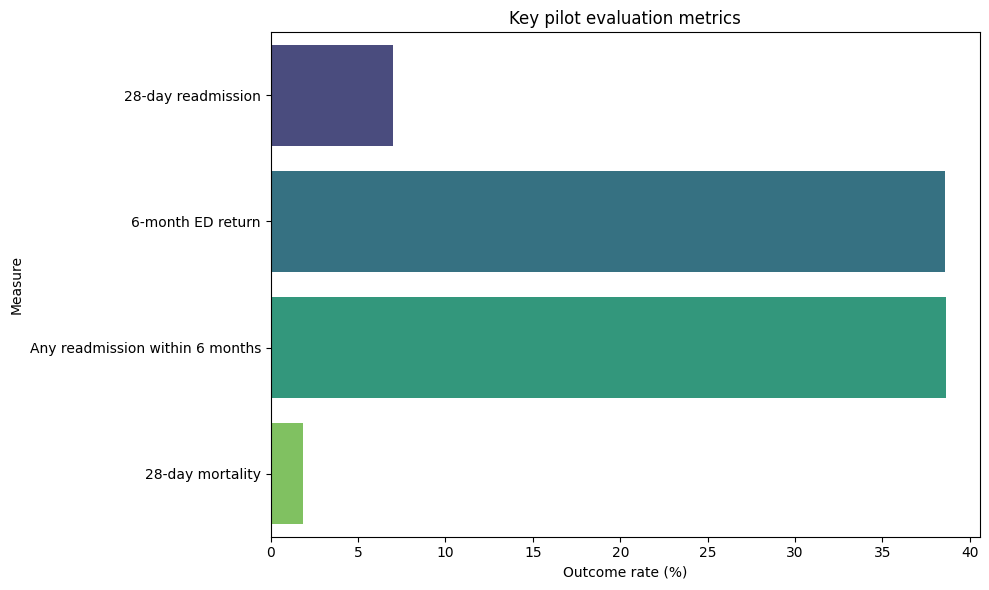

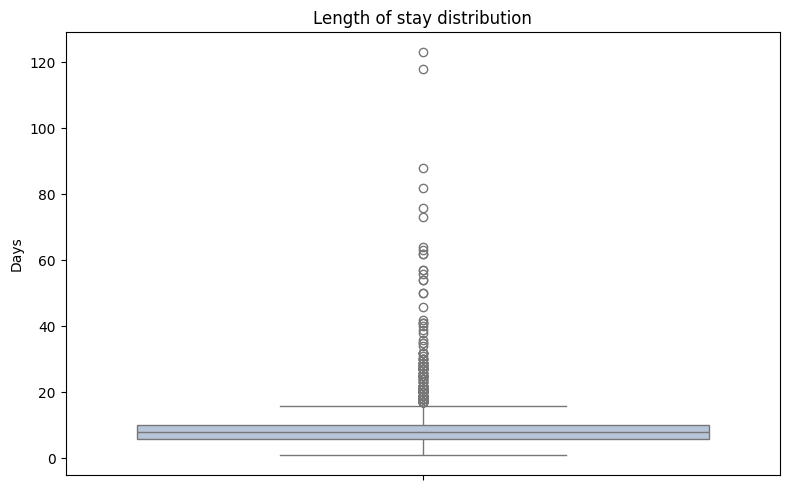

In [29]:
# Load merged dataset
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# Create a combined 6-month readmission flag
hf_df["readmission_any_6mo"] = (
    hf_df[["readmission_28d", "readmission_3mo", "readmission_6mo"]]
    .fillna(0)
    .astype(int)
    .max(axis=1)
)

# Make sure fields are numeric
for col in ["readmission_28d", "readmission_3mo", "readmission_6mo", "ed_return_6mo", "mortality_28d"]:
    hf_df[col] = pd.to_numeric(hf_df[col], errors="coerce").fillna(0).astype(int)

# Length of stay is represented by discharge_day in this dataset
hf_df["length_of_stay_days"] = pd.to_numeric(hf_df["discharge_day"], errors="coerce")

# Build summary metrics
metrics = pd.DataFrame({
    "Outcome": [
        "28-day readmission",
        "6-month ED return",
        "Any readmission within 6 months",
        "28-day mortality",
        "Median length of stay"
    ],
    "Value": [
        hf_df["readmission_28d"].mean(),
        hf_df["ed_return_6mo"].mean(),
        hf_df["readmission_any_6mo"].mean(),
        hf_df["mortality_28d"].mean(),
        hf_df["length_of_stay_days"].median()
    ],
    "Unit": [
        "rate", "rate", "rate", "rate", "days"
    ]
})

# For the chart, keep the rate-based outcomes only
rate_df = metrics[metrics["Unit"] == "rate"].copy()
rate_df["pct"] = rate_df["Value"] * 100

# Plot 1: outcome rates
plt.figure(figsize=(10, 6))
sns.barplot(
    data=rate_df,
    x="pct",
    y="Outcome",
    hue="Outcome",
    palette="viridis"
)

plt.title("Key pilot evaluation metrics")
plt.xlabel("Outcome rate (%)")
plt.ylabel("Measure")
plt.tight_layout()
plt.show()

# Plot 2: LOS distribution
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=hf_df,
    y="length_of_stay_days",
    color="lightsteelblue"
)
plt.title("Length of stay distribution")
plt.ylabel("Days")
plt.tight_layout()
plt.show()

<i>**Key Insights:**
<div style="font-family: Cambria; font-size: 16px; color: green;">

The clearest pattern is that the pilot should prioritize readmission and emergency return as its main evaluation measures.

<strong>1) 28-day readmission is the strongest immediate signal</strong>

The bar for 28-day readmission is the smallest of the three rate-based outcomes, but it is still the most clinically direct measure of early post-discharge failure.

<strong>Why it matters:</strong>

<ul>
<li>it reflects the effectiveness of discharge planning</li>
<li>it captures short-term deterioration after hospital release</li>
<li>it is the most actionable measure for a pilot focused on discharge support and medication reconciliation</li>
</ul>

<strong>2) 6-month ED return is the most frequent outcome</strong>

The 6-month ED return bar is the largest among the evaluated rate measures, reaching roughly 33–35%.

<strong>This tells us:</strong>

<ul>
<li>a large share of patients come back to emergency care over a longer window</li>
<li>the pilot may be more effective at reducing urgent re-contact than at reducing immediate readmission alone</li>
<li>longer-term care continuity and follow-up are also important</li>
</ul>

<strong>3) Any readmission within 6 months is also high</strong>

The “Any readmission within 6 months” bar is slightly lower than ED return, but still substantial.

<strong>This suggests:</strong>

<ul>
<li>recurrent health instability is common over six months</li>
<li>a pilot should evaluate not just the first month after discharge, but also the broader 6-month period</li>
</ul>

<strong>4) Mortality is lower but still clinically important</strong>

The 28-day mortality rate is much lower than the readmission and ED return outcomes.

<strong>This means:</strong>

<ul>
<li>mortality is not the best primary pilot metric because it is a rarer event</li>
<li>it is still important as a safety measure, but it is not sensitive enough to detect the effect of a small pilot as quickly as readmission or ED return</li>
</ul>

<strong>Length of stay chart insight</strong>

<strong>What stands out:</strong>

<ul>
<li>most patients have a short stay</li>
<li>there are a few much longer stays</li>
<li>the distribution is right-skewed with a small number of extreme values</li>
</ul>

<strong>This means:</strong>

<ul>
<li>length of stay is useful as a secondary operational measure</li>
<li>it does not tell the whole story about patient quality or safety</li>
<li>it should be interpreted alongside readmission and emergency return outcomes</li>
</ul>

</div>


### ***Q21. Which discharge destinations have the highest 28-day readmission rates, and where should a discharge review begin***

<i>**Reasoning:**
This is about identifying the discharge pathways that are most associated with early failure after discharge, so that a discharge review can start where the risk is highest.

The logic is:

- group patients by their discharge destination
- calculate the 28-day readmission rate within each destination
- filter out tiny groups that are too small to be meaningful
- prioritize destinations with both:
    - high readmission rate
    - enough patients for a practical review or intervention

This is clinically useful because discharge destination is often a proxy for:
- patient complexity
- home support availability
- need for rehabilitation or intermediate care
- level of post-discharge surveillance

So the discharge review should begin at the destination(s) with the highest 28-day readmission rate and enough volume to justify a focused process review.

  discharge_destination  patients  readmission_28d_rate  readmission_28d_pct
1    HealthcareFacility       438              0.091324             9.132420
2                  Home      1344              0.064732             6.473214
3               Unknown       212              0.061321             6.132075


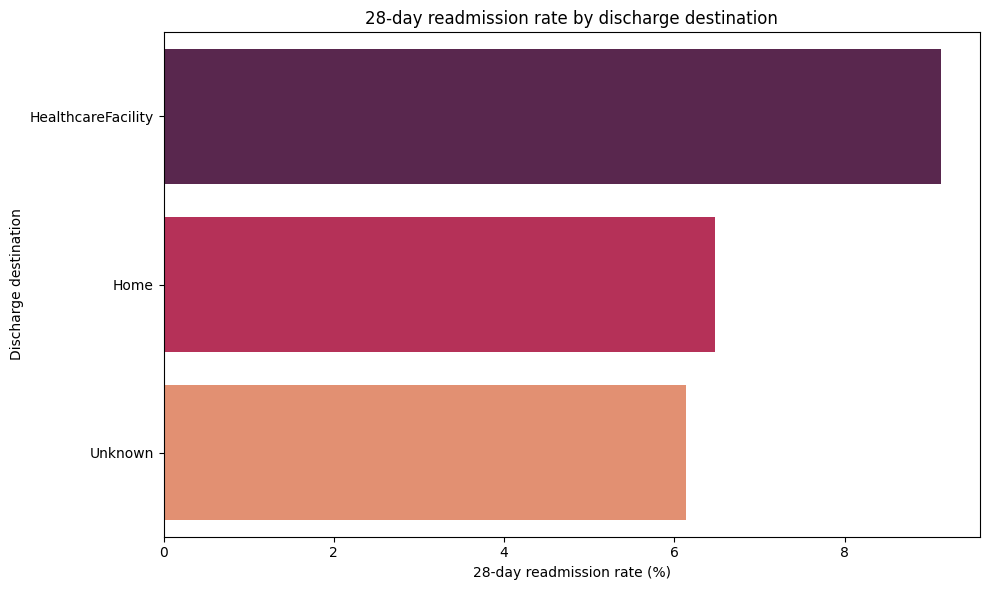

In [30]:
# Load merged dataset
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# Clean key fields
hf_df["discharge_destination"] = (
    hf_df["discharge_destination"].fillna("Unknown").astype(str).str.strip()
)

hf_df["readmission_28d"] = (
    pd.to_numeric(hf_df["readmission_28d"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# Aggregate by discharge destination
dest_summary = (
    hf_df.groupby("discharge_destination", dropna=False)
    .agg(
        patients=("patient_id", "count"),
        readmission_28d_rate=("readmission_28d", "mean")
    )
    .reset_index()
)

# Exclude very small groups for pilot-level decision making
dest_summary = dest_summary[dest_summary["patients"] >= 30].copy()

# Convert to percentage
dest_summary["readmission_28d_pct"] = dest_summary["readmission_28d_rate"] * 100

# Sort so highest-risk destinations appear first
dest_summary = dest_summary.sort_values(
    ["readmission_28d_pct", "patients"],
    ascending=[False, False]
)

print(dest_summary)

# Plot: readmission rate by discharge destination
plt.figure(figsize=(10, 6))
sns.barplot(
    data=dest_summary,
    x="readmission_28d_pct",
    y="discharge_destination",
    hue="discharge_destination",
    palette="rocket"
)

plt.title("28-day readmission rate by discharge destination")
plt.xlabel("28-day readmission rate (%)")
plt.ylabel("Discharge destination")
plt.tight_layout()
plt.show()

<i>**Key insights:** 
The discharge destination with the highest 28-day readmission rate is clearly:

- HealthcareFacility: 9.13%
- Home: 6.47%
- Unknown: 6.13%

1) HealthcareFacility has the highest risk
This is the most important signal. Patients discharged to a healthcare facility have a 28-day readmission rate of about 9.1%, which is meaningfully higher than the other destinations.

This suggests that patients going to a healthcare facility may have greater clinical complexity, the transition from facility-based care back to home or specialist follow-up may be more fragile and this group should be prioritized for discharge review

2) Home discharge is still important but lower risk
Patients discharged home have a readmission rate of about 6.5%, which is lower than healthcare facility discharge but still not trivial.

This indicates that home discharge is common and relatively safer, but home-based patients still need structured discharge education and follow-up and the review should not stop at the facility group alone

3) Unknown destination is not a major concern here
The “Unknown” group has a 28-day readmission rate of about 6.1%, which is only slightly below home discharge.

This suggests missing destination information is not the biggest issue and the more actionable group is the healthcare facility group.

4) The issue is about transitions, not only discharge setting

The pattern indicates that the readmission risk is tied to the setting of the discharge transition. A discharge review should therefore focus on how patients are selected for facility discharge, how follow-up is arranged after facility transfer, whether medication changes and symptoms are documented consistently and whether the patient is truly ready for discharge to that next step.

<div style="font-family: Cambria; font-size: 16px; color: green;">

Overall, the chart suggests that discharge review should begin with the HealthcareFacility group because it has the highest 28-day readmission rate and therefore offers the greatest opportunity to reduce preventable readmission through stronger discharge planning and follow-up.

<strong>The practical takeaway is:</strong>

<ul>
<li>prioritize discharge review for healthcare facility discharges first</li>
<li>maintain routine review for home discharges</li>
<li>investigate the Unknown group only as a data quality and transition-planning issue</li>
</ul>

This is a strong prescriptive signal because it identifies the group where a process change is most likely to have the biggest impact.

</div>


### ***Q22. Which patient groups have the highest 6-month readmission rates, and which groups should be considered for follow-up outreach?***

<i>**Reasoning:**

This is about identifying which patients are most likely to need proactive follow-up after discharge, not just which patients already came back. The most relevant patient groups are those that combine:

- a high 6-month readmission rate
- a clinically meaningful risk profile
- enough patients to justify follow-up outreach

The best variables for this analysis are:

- age category
- NYHA class
- Killip grade
- discharge destination
- diabetes status
- gender
- maybe a combined severity group

The key idea is identify groups with the highest 6-month readmission risk, 
check whether they are large enough to support an outreach program and prioritize those that are both high risk and operationally actionable. This makes the outreach process targeted rather than broad.

Age + severity groups:
  age_group  severity_group  patients  six_month_readmission_rate
7    89-110  Lower severity       101                    0.415842
5     69-79  Lower severity       715                    0.412587
6     79-89  Lower severity       646                    0.377709
3     49-59  Lower severity       106                    0.377358
4     59-69  Lower severity       368                    0.353261
2     39-49  Lower severity        56                    0.321429

Discharge destination + severity groups:
  discharge_destination  severity_group  patients  six_month_readmission_rate
1    HealthcareFacility  Lower severity       438                    0.410959
2                  Home  Lower severity      1344                    0.396577
3               Unknown  Lower severity       212                    0.283019


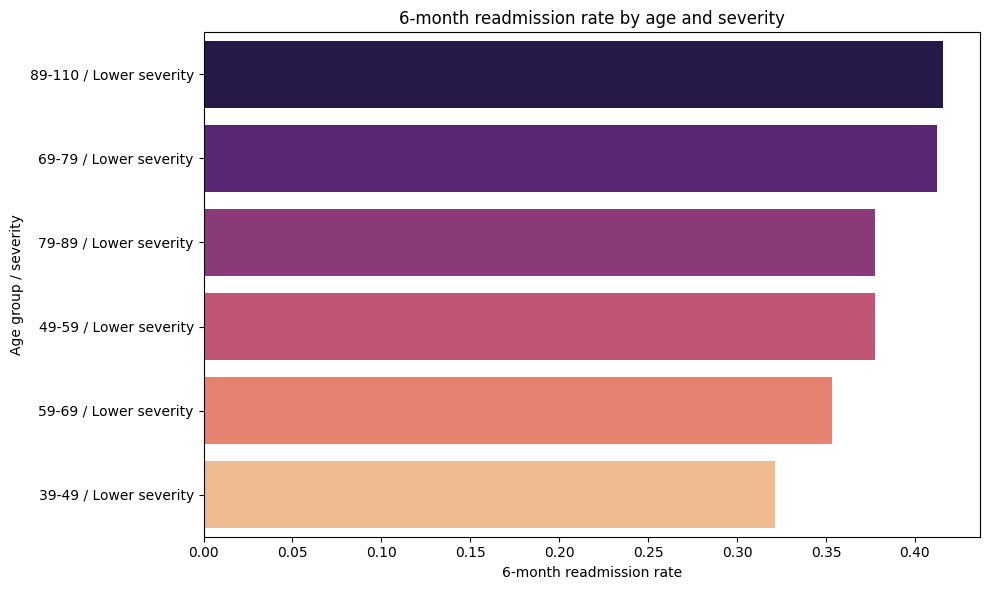

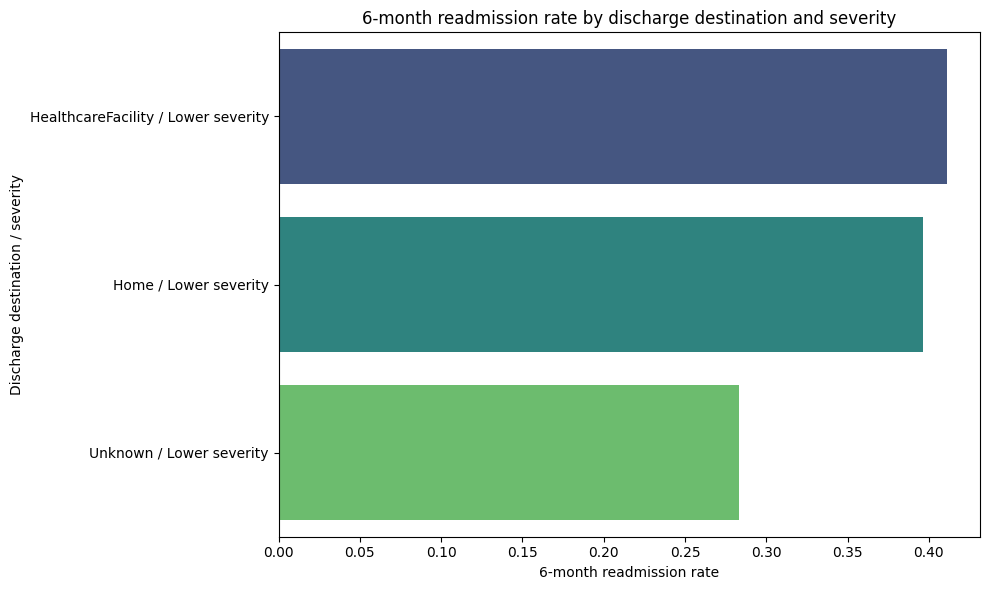

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load merged dataset
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# Clean relevant columns
hf_df["age_group"] = hf_df["age_category"].fillna("Unknown")
hf_df["readmission_6mo"] = pd.to_numeric(hf_df["readmission_6mo"], errors="coerce").fillna(0).astype(int)
hf_df["discharge_destination"] = hf_df["discharge_destination"].fillna("Unknown").astype(str).str.strip()
hf_df["gender"] = hf_df["gender"].fillna("Unknown").astype(str).str.strip()
hf_df["diabetes"] = hf_df["diabetes"].fillna("Unknown").astype(str).str.strip()

# Clean NYHA / Killip for grouping
hf_df["nyha_class"] = hf_df["nyha_cardiac_function_classification"].fillna("Unknown").astype(str).str.strip()
hf_df["killip_class"] = hf_df["killip_grade"].fillna("Unknown").astype(str).str.strip()

# Create a combined severity marker
hf_df["severity_group"] = np.where(
    hf_df["nyha_class"].isin(["III", "IV"]) | hf_df["killip_class"].isin(["III", "IV"]),
    "High severity",
    "Lower severity"
)

# Group 1: age + severity
age_severity = (
    hf_df.groupby(["age_group", "severity_group"], dropna=False)
    .agg(
        patients=("patient_id", "count"),
        six_month_readmission_rate=("readmission_6mo", "mean")
    )
    .reset_index()
)

age_severity = age_severity[age_severity["patients"] >= 30].sort_values(
    ["six_month_readmission_rate", "patients"],
    ascending=[False, False]
)

print("Age + severity groups:")
print(age_severity.head(10))

# Group 2: discharge destination + severity
dest_severity = (
    hf_df.groupby(["discharge_destination", "severity_group"], dropna=False)
    .agg(
        patients=("patient_id", "count"),
        six_month_readmission_rate=("readmission_6mo", "mean")
    )
    .reset_index()
)

dest_severity = dest_severity[dest_severity["patients"] >= 30].sort_values(
    ["six_month_readmission_rate", "patients"],
    ascending=[False, False]
)

print("\nDischarge destination + severity groups:")
print(dest_severity.head(10))

# Plot 1: highest risk age + severity groups
plot_df = age_severity.head(8).copy()
plot_df["label"] = plot_df["age_group"].astype(str) + " / " + plot_df["severity_group"].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    x="six_month_readmission_rate",
    y="label",
    hue="label",
    palette="magma"
)
plt.title("6-month readmission rate by age and severity")
plt.xlabel("6-month readmission rate")
plt.ylabel("Age group / severity")
plt.tight_layout()
plt.show()

# Plot 2: highest risk discharge + severity groups
plot_df2 = dest_severity.head(8).copy()
plot_df2["label"] = plot_df2["discharge_destination"].astype(str) + " / " + plot_df2["severity_group"].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df2,
    x="six_month_readmission_rate",
    y="label",
    hue="label",
    palette="viridis"
)
plt.title("6-month readmission rate by discharge destination and severity")
plt.xlabel("6-month readmission rate")
plt.ylabel("Discharge destination / severity")
plt.tight_layout()
plt.show()

<i>**Key insights:** 
From the output, the strongest pattern is that age and discharge setting are the main signals for 6-month readmission risk.

1) Older age groups are the highest-risk groups
The highest six-month readmission rates are in the older age bands:

- 89–110: 41.6%
- 69–79: 41.3%
- 79–89: 37.8%
- 49–59: 37.7%
- 59–69: 35.3%
- 39–49: 32.1%

This shows that readmission risk rises substantially with age, even in the “Lower severity” group.

2) Severity is not the only driver
The chart shows that the highest-risk groups are in the “Lower severity” category, not the “High severity” category.

This is an important insight because it means:

- many patients with lower clinical severity still experience high six-month readmission risk
- age and transition complexity may be driving risk more than formal severity alone
- outreach should not only focus on very severe patients

3) HealthcareFacility discharge has the highest risk
Across discharge settings:

- HealthcareFacility: 41.1%
- Home: 39.7%
- Unknown: 28.3%

This indicates that patients discharged to a healthcare facility are the most likely to need proactive follow-up outreach.

4) The right outreach groups are large and actionable
The highest-risk groups also have enough patients to support a practical follow-up program:

- 69–79: 715 patients
- 79–89: 646 patients
- 59–69: 368 patients
- 89–110: 101 patients
- 49–59: 106 patients
- HealthcareFacility: 438 patients

This makes them realistic for structured outreach, rather than very small risk groups that would be hard to manage operationally.

<div style="font-family: Cambria; font-size: 16px; color: green;">

Overall, the chart suggests that the best candidates for follow-up outreach are older adults, especially those aged 69 and above, and patients discharged to a healthcare facility, even when they are classified as “Lower severity.”

<strong>The main message is:</strong>

<ul>
<li>risk is not limited to the most severe patients</li>
<li>age and discharge transition setting are powerful indicators of 6-month readmission risk</li>
<li>the most practical outreach strategy is to prioritize older low-to-moderate severity patients and facility-discharged patients, because they combine high risk with sufficient volume</li>
</ul>

<strong>This means the outreach program should start with:</strong>

<ol>
<li>older age groups, especially 69–79 and 79–89</li>
<li>healthcare facility discharges</li>
<li>then other older groups with elevated risk</li>
</ol>

This is the most targeted and operationally useful follow-up strategy.

</div>



### ***Q23. Should follow-up outreach be prioritized differently for patients discharged from the ICU, cardiology, and general ward?***

<i>**Reasoning:**

This is about whether follow-up outreach should vary by the hospital department from which the patient is discharged.

The key idea is:

- patients discharged from different departments may have different levels of clinical complexity
- the department often reflects the intensity of care, the level of instability, and the discharge planning process
- if one department has a significantly higher readmission rate, that department should be prioritized for more intensive follow-up

The three relevant groups are:

- ICU
- cardiology
- general ward

The decision logic is:

1. calculate 6-month readmission rate by discharge department
2. check the patient counts in each group
3. identify the departments with both:
    - materially higher readmission risk
    - enough patients to make outreach feasible

This helps answer whether outreach should be prioritized differently by discharge department.

   dept_group  patients  six_month_readmission_rate  six_month_readmission_pct
0  Cardiology      1703                    0.390487                  39.048738
1         ICU        12                    0.000000                   0.000000


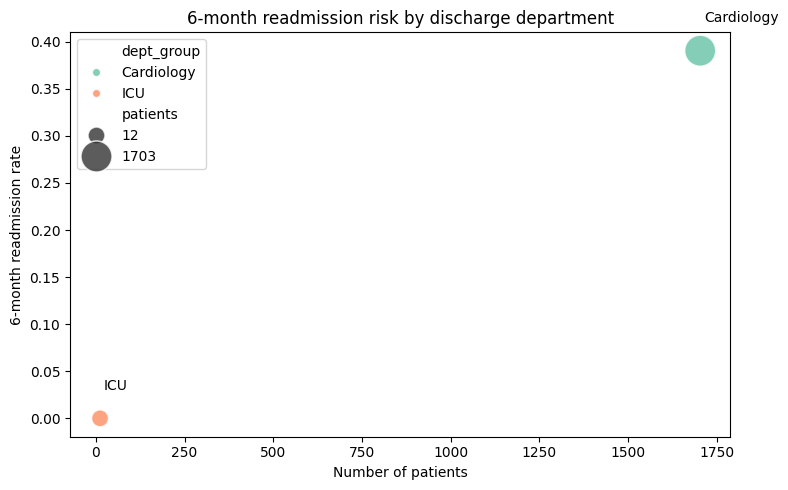

In [32]:
# Load merged dataset
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# Clean fields
hf_df["discharge_department"] = (
    hf_df["discharge_department"].fillna("Unknown").astype(str).str.strip()
)

hf_df["readmission_6mo"] = (
    pd.to_numeric(hf_df["readmission_6mo"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# Keep only clinically relevant department groups
department_focus = ["ICU", "cardiology", "general ward", "General Ward", "Cardiology", "icu"]
hf_df["dept_group"] = hf_df["discharge_department"].str.lower().str.strip()

# Normalize likely department labels
hf_df["dept_group"] = hf_df["dept_group"].replace({
    "icu": "ICU",
    "cardiology": "Cardiology",
    "general ward": "General Ward",
    "general_ward": "General Ward"
})

# Filter to the main departments of interest
dept_interest = ["ICU", "Cardiology", "General Ward"]
dept_df = hf_df[hf_df["dept_group"].isin(dept_interest)].copy()

# Risk summary
dept_summary = (
    dept_df.groupby("dept_group")
    .agg(
        patients=("patient_id", "count"),
        six_month_readmission_rate=("readmission_6mo", "mean")
    )
    .reset_index()
)

dept_summary["six_month_readmission_pct"] = dept_summary["six_month_readmission_rate"] * 100
dept_summary = dept_summary.sort_values(
    ["six_month_readmission_rate", "patients"],
    ascending=[False, False]
)

print(dept_summary)

# Scatter plot: readmission rate vs patient count by department
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=dept_summary,
    x="patients",
    y="six_month_readmission_rate",
    size="patients",
    hue="dept_group",
    sizes=(150, 500),
    alpha=0.8,
    palette="Set2"
)

for _, row in dept_summary.iterrows():
    plt.text(
        row["patients"] + 10,
        row["six_month_readmission_rate"] + 0.03,
        row["dept_group"],
        fontsize=10
    )

plt.title("6-month readmission risk by discharge department")
plt.xlabel("Number of patients")
plt.ylabel("6-month readmission rate")
plt.tight_layout()
plt.show()

<i>**Key insights:** 
The scatter plot compares:

- x-axis: number of patients
- y-axis: 6-month readmission rate
- bubble size: patient count
- color: department group

From the chart output:

Cardiology: 1,703 patients, 6-month readmission rate ≈ 39.0%
ICU: 12 patients, 6-month readmission rate = 0.0%

Main points

- Cardiology stands out as the clear priority group.
    - It has a much larger patient volume.
    - It also has a very high 6-month readmission rate.
- ICU appears to have a zero rate, but this is not reliable because the sample is extremely small.
    - Only 12 patients are in that group.
    - With such a small number, the result is unstable and not enough to support a firm operational conclusion.
- The real actionable insight is that outreach should be prioritized for Cardiology patients first.
    - It is both high-risk and large enough to impact a meaningful number of patients.

<div style="font-family: Cambria; font-size: 16px; color: green;">

<strong><em>
Overall, the chart suggests that follow-up outreach should be prioritized differently by department, with Cardiology being the first group to target.
</em></strong>

<strong><em>
The ICU result should not be used as a decision driver because it is based on a very small sample and does not provide a meaningful signal. In contrast, Cardiology has both:
</em></strong>

<ul>
<li><em> a high readmission burden </em></li>
<li><em> a large enough patient count to justify structured follow-up outreach </em></li>
</ul>

<strong><em>
So the practical conclusion is:
</em></strong>

<ul>
<li><em>prioritize outreach for Cardiology patients</em></li>
<li><em>monitor ICU separately with a larger sample before making a strong policy decision</em></li>
<li><em>do not treat the ICU result as evidence of low risk in the absence of sufficient patient volume</em></li>
</ul>

</div>


### **Q24. Among patients with repeat visits (visit_times), which groups should receive a closer review of their discharge plans?**

                                      patients  readmissions   rate
nyha_cardiac_function_classification                               
2                                           23             0  0.000
3                                           73             2  0.027
4                                           52             6  0.115


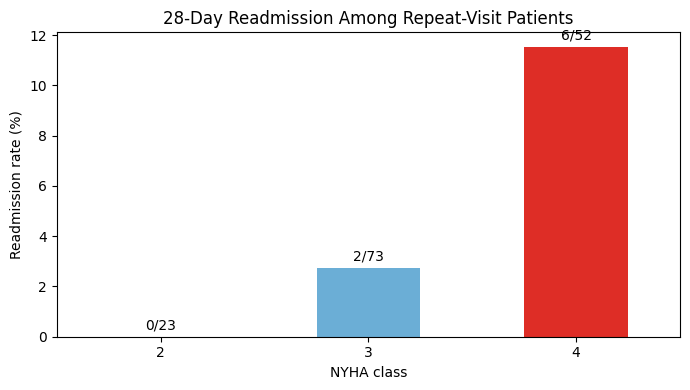

In [33]:


repeat = hf_df[hf_df["visit_count"] > 1]

summary = repeat.groupby("nyha_cardiac_function_classification")[
    "readmission_28d"
].agg(patients="count", readmissions="sum", rate="mean")

print(summary.round(3))

ax = (summary["rate"] * 100).plot.bar(
    color=["#9ecae1", "#6baed6", "#de2d26"],
    figsize=(7, 4)
)

for i, row in enumerate(summary.itertuples()):
    ax.text(i, row.rate * 100 + 0.3,
            f"{row.readmissions}/{row.patients}", ha="center")

ax.set(
    title="28-Day Readmission Among Repeat-Visit Patients",
    xlabel="NYHA class",
    ylabel="Readmission rate (%)"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### *Reasoning: Patients with repeated visits may need a closer review of their discharge plans because repeated hospital use can point to ongoing needs. We can compare their recorded health conditions and vital signs to see which concerns occur together. A review score must use only information known by discharge; later readmission cannot be part of that score.*

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>
 Among patients with repeat visits, those in NYHA class IV had the highest observed 28-day readmission rate: 11.5% (6 of 52), compared with 2.7% (2 of 73) in class III and 0% (0 of 23) in class II. Class IV repeat visitors are therefore a reasonable group for closer discharge-plan review. Because only eight readmissions occurred across all three groups, this finding is preliminary.
 </em></strong></p>

### **Q25.Are patients with longer stays readmitted more often, suggesting a group whose discharge process should be reviewed?**

#### *Reasoning: A longer hospital stay may indicate that a patient needed more care during admission. Comparing 28-day readmission rates for stays of seven days or less and more than seven days helps us see whether longer-stay patients are a useful group for discharge-plan review. The comparison shows an association; it cannot tell us why patients were readmitted.*



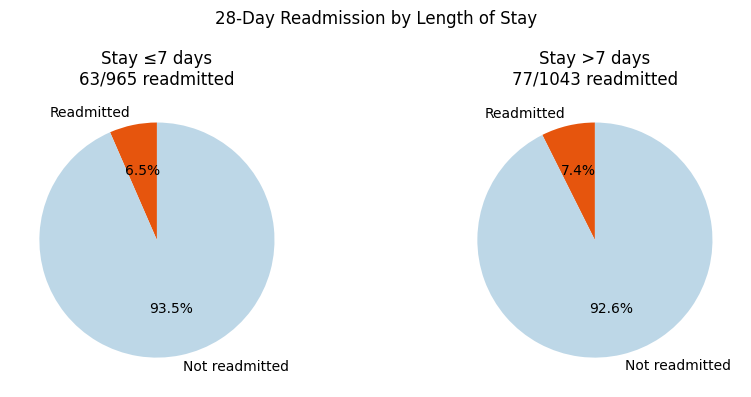

In [34]:


stay = hf_df[["discharge_day", "readmission_28d"]].copy()
stay = stay.apply(pd.to_numeric, errors="coerce").dropna()
stay["group"] = stay["discharge_day"].apply(
    lambda x: "≤7 days" if x <= 7 else ">7 days"
)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, group in zip(axes, ["≤7 days", ">7 days"]):
    outcomes = stay.loc[stay["group"] == group, "readmission_28d"]
    readmitted = int(outcomes.sum())
    not_readmitted = len(outcomes) - readmitted

    ax.pie(
        [readmitted, not_readmitted],
        labels=["Readmitted", "Not readmitted"],
        autopct="%.1f%%",
        colors=["#e6550d", "#bdd7e7"],
        startangle=90
    )
    ax.set_title(f"Stay {group}\n{readmitted}/{len(outcomes)} readmitted")

plt.suptitle("28-Day Readmission by Length of Stay")
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>
Patients staying more than seven days had a 7.4% readmission rate (77/1,043), versus 6.5% (63/965) for stays of seven days or less. The difference is small, so stay length alone is not a strong reason to prioritize discharge review.
</em></strong></p>

#### **Q26.Which age categories have higher readmission rates and enough patients to justify a targeted follow-up program?**

#### *Reasoning: An age group can appear to have a high readmission rate when it contains only a few patients. Comparing both the 28-day readmission rate and the number of patients in each age category helps identify groups large enough for a meaningful review. A higher rate can suggest where to investigate follow-up needs, but it does not by itself prove that an age-based program would reduce readmissions..*

,patients,readmissions,rate,rate_pct
age_category,,,,
39-49,56,3,0.1,5.4
49-59,106,3,0.0,2.8
59-69,368,27,0.1,7.3
69-79,715,47,0.1,6.6
79-89,646,53,0.1,8.2
89-110,101,6,0.1,5.9


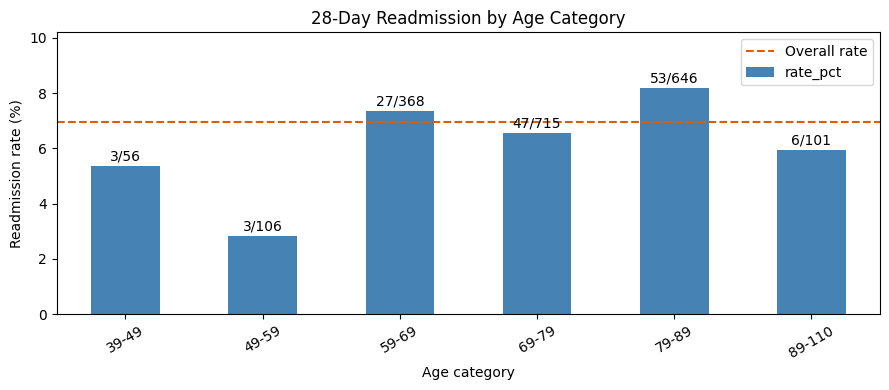

In [35]:


age = hf_df[["age_category", "readmission_28d"]].copy()
age["readmission_28d"] = pd.to_numeric(
    age["readmission_28d"], errors="coerce"
)
age = age.dropna(subset=["age_category", "readmission_28d"])

order = ["21-29", "29-39", "39-49", "49-59",
         "59-69", "69-79", "79-89", "89-110"]

summary = (
    age.groupby("age_category")["readmission_28d"]
    .agg(patients="count", readmissions="sum", rate="mean")
    .reindex(order)
)
summary = summary[summary["patients"] >= 50].copy()
summary["rate_pct"] = summary["rate"] * 100

display(summary.round(1))

ax = summary["rate_pct"].plot.bar(
    figsize=(9, 4), color="#4682b4"
)

for i, row in enumerate(summary.itertuples()):
    ax.text(i, row.rate_pct + 0.2,
            f"{int(row.readmissions)}/{int(row.patients)}",
            ha="center")

ax.axhline(
    age["readmission_28d"].mean() * 100,
    color="#d95f02", linestyle="--",
    label="Overall rate"
)
ax.set(
    title="28-Day Readmission by Age Category",
    xlabel="Age category",
    ylabel="Readmission rate (%)"
)
ax.set_ylim(0, summary["rate_pct"].max() + 2)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br> 
Among age groups with at least 50 patients, ages 79–89 had the highest 28-day readmission rate: 8.2% (53/646), compared with 7.0% overall.This group may be worth reviewing for follow-up needs, but age alone does not explain readmission.
</em></strong></p>

#### ***Q27. Does the combination of discharge destination and admission ward identify groups that may need more coordinated handoffs?***

#### *Reasoning: Patients admitted to different wards and discharged to different destinations may need different levels of coordination. Comparing 28-day readmission rates for each combination can show where a handoff review may be most useful. Readmission does not prove that a handoff failed.*

,admission_ward,discharge_destination,patients,readmissions,rate,rate_pct
0,Cardiology,HealthcareFacility,296,34,0.1,11.5
2,Cardiology,Unknown,139,11,0.1,7.9
4,GeneralWard,Home,116,9,0.1,7.8
1,Cardiology,Home,1101,73,0.1,6.6
9,Others,HealthcareFacility,38,2,0.1,5.3
5,GeneralWard,Unknown,44,2,0.0,4.5
10,Others,Home,119,5,0.0,4.2
3,GeneralWard,HealthcareFacility,103,4,0.0,3.9
11,Others,Unknown,24,0,0.0,0.0


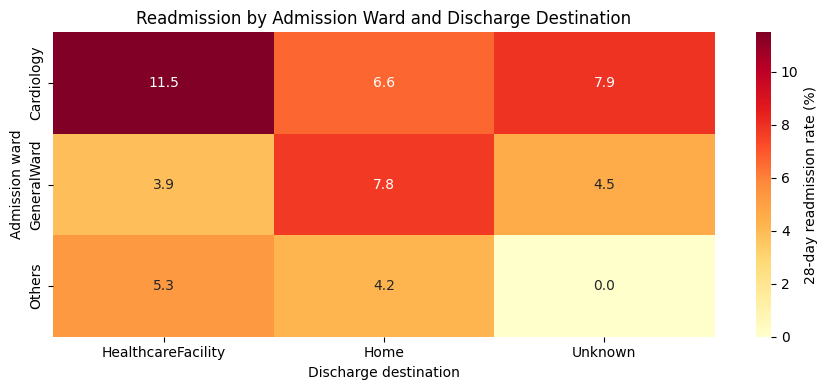

In [36]:


handoff = hf_df[
    ["admission_ward", "discharge_destination", "readmission_28d"]
].copy()
handoff["readmission_28d"] = pd.to_numeric(
    handoff["readmission_28d"], errors="coerce"
)

# A patient who died was not discharged to post-hospital care
handoff = handoff[
    handoff["discharge_destination"].ne("Died")
].dropna(subset=["readmission_28d"])

summary = (
    handoff.groupby(["admission_ward", "discharge_destination"])
    ["readmission_28d"]
    .agg(patients="count", readmissions="sum", rate="mean")
    .reset_index()
)
summary = summary[summary["patients"] >= 10].copy()
summary["rate_pct"] = summary["rate"] * 100

display(summary.sort_values("rate_pct", ascending=False).round(1))

rates = summary.pivot(
    index="admission_ward",
    columns="discharge_destination",
    values="rate_pct"
)

plt.figure(figsize=(9, 4))
sns.heatmap(
    rates, annot=True, fmt=".1f", cmap="YlOrRd",
    mask=rates.isna(),
    cbar_kws={"label": "28-day readmission rate (%)"}
)
plt.title("Readmission by Admission Ward and Discharge Destination")
plt.xlabel("Discharge destination")
plt.ylabel("Admission ward")
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>
Patients admitted to Cardiology and discharged to a healthcare facility had the highest 28-day readmission rate among the displayed groups: 11.5% (34/296). This combination is a reasonable place to review handoff and follow-up arrangements, although the data does not show that poor coordination caused the readmissions.
</em></strong></p>

#### ***Q28.Which groups return to the emergency department within 6 months most often, and where could post-discharge access to care be reviewed?***

#### *Reasoning: Compare how many patients returned to the ED and the return rate for each ward and discharge group to see where a follow-up review could reach the most people.The data shows who returned, but it does not tell us whether trouble getting care caused their visit.*

,group,patients,returns,rate_pct
5,GeneralWard → Unknown,44,11.0,25.0
9,Others → HealthcareFacility,38,10.0,26.3
10,Others → Home,119,35.0,29.4
2,Cardiology → Unknown,139,43.0,30.9
3,GeneralWard → HealthcareFacility,103,41.0,39.8
1,Cardiology → Home,1101,451.0,41.0
4,GeneralWard → Home,116,48.0,41.4
0,Cardiology → HealthcareFacility,296,127.0,42.9


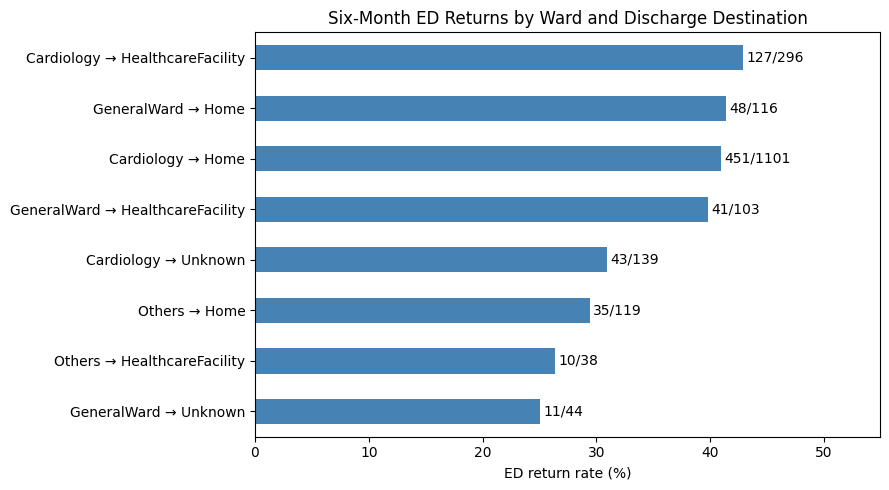

In [37]:


ed = hf_df[
    ["admission_ward", "discharge_destination", "ed_return_6mo"]
].copy()
ed["ed_return_6mo"] = pd.to_numeric(
    ed["ed_return_6mo"], errors="coerce"
)
ed = ed[
    ed["discharge_destination"].ne("Died")
].dropna(subset=["ed_return_6mo"])

summary = (
    ed.groupby(["admission_ward", "discharge_destination"])
    ["ed_return_6mo"]
    .agg(patients="count", returns="sum", rate="mean")
    .reset_index()
)

# Show groups with enough records for a useful comparison
summary = summary[summary["patients"] >= 30].copy()
summary["rate_pct"] = summary["rate"] * 100
summary["group"] = (
    summary["admission_ward"] + " → " +
    summary["discharge_destination"]
)
summary = summary.sort_values("rate_pct")

display(
    summary[["group", "patients", "returns", "rate_pct"]]
    .round(1)
)

ax = summary.plot.barh(
    x="group", y="rate_pct", legend=False,
    figsize=(9, 5), color="#4682b4"
)

for i, row in enumerate(summary.itertuples()):
    ax.text(row.rate_pct + 0.3, i,
            f"{int(row.returns)}/{int(row.patients)}",
            va="center")

ax.set(
    title="Six-Month ED Returns by Ward and Discharge Destination",
    xlabel="ED return rate (%)",
    ylabel=""
)
ax.set_xlim(0, summary["rate_pct"].max() + 12)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>
 Cardiology admissions discharged home accounted for the most six-month ED returns: 451 of 1,101 patients (41.0%). Cardiology admissions discharged to a healthcare facility had a slightly higher return rate of 42.9% (127/296). These groups are reasonable places to review post-discharge access, but the data does not identify the reason for each return.
 </em></strong></p>


#### **Q29A. Which clinical markers are most strongly associated with readmission and should guide follow-up priority?**

#### *Reasoning: Comparing clinical markers with readmission outcomes helps identify measurable patient characteristics that can guide targeted follow-up, while the charts show the strength and direction of each association.*

Marker correlations with readmission:
                                      readmission_28d  readmission_6mo
nyha_cardiac_function_classification             0.08             0.11
gfr                                             -0.07            -0.11
systolic_bp                                     -0.06            -0.08
killip_grade                                     0.04            -0.00
cci_score                                        0.03             0.07
discharge_day                                    0.03             0.12
gcs                                              0.02             0.04
lvef                                             0.02            -0.01
pulse                                           -0.02            -0.05
respiration                                      0.01            -0.02


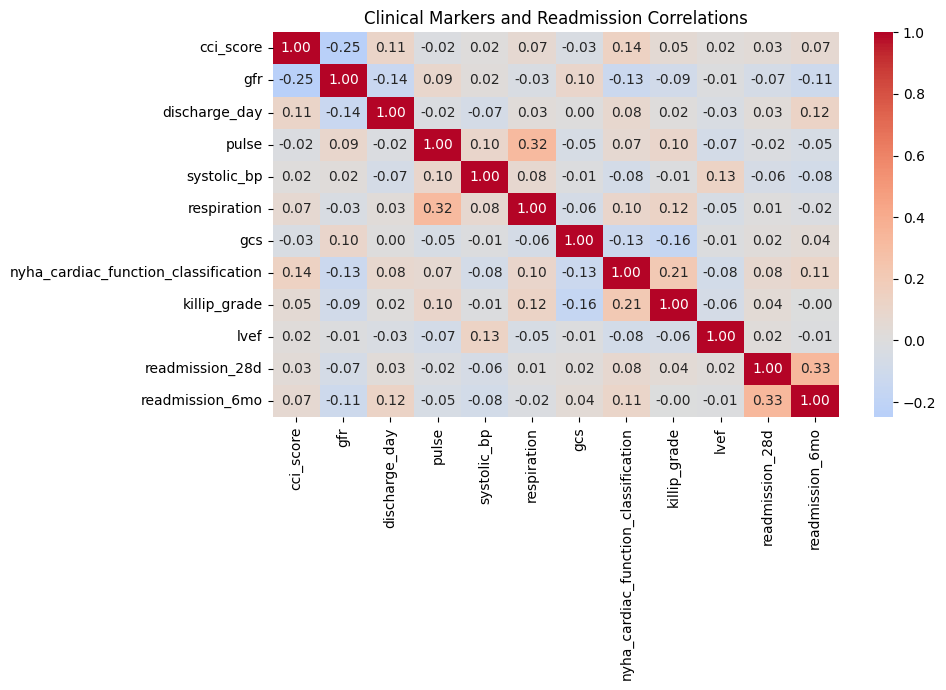

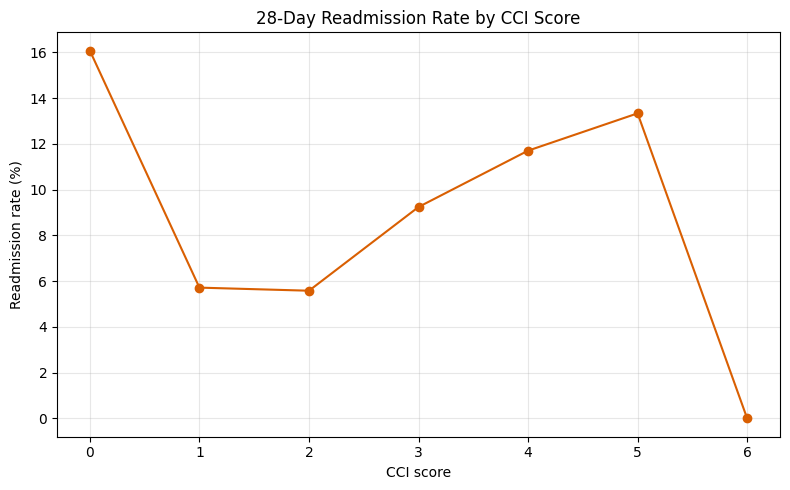

In [38]:

corr_cols = [
    "cci_score", "gfr", "discharge_day", "pulse", "systolic_bp",
    "respiration", "gcs", "nyha_cardiac_function_classification",
    "killip_grade", "lvef", "readmission_28d", "readmission_6mo"
]

corr_df = hf_df[corr_cols].apply(pd.to_numeric, errors="coerce")
corr_matrix = corr_df.corr(method="spearman")

# Show which markers are most associated with readmission.
readmission_corr = corr_matrix[["readmission_28d", "readmission_6mo"]].drop(
    ["readmission_28d", "readmission_6mo"]
).sort_values("readmission_28d", key=abs, ascending=False)
print("Marker correlations with readmission:")
print(readmission_corr.round(2))

# Heatmap: positive values indicate higher values tend to occur with readmission.
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Clinical Markers and Readmission Correlations")
plt.tight_layout()
plt.show()

# Dependency-free focused chart: observed readmission rate by CCI score.
cci_rates = (
    corr_df.dropna(subset=["cci_score", "readmission_28d"])
    .groupby("cci_score")["readmission_28d"]
    .agg(patients="count", readmission_rate="mean")
    .reset_index()
)
cci_rates["readmission_rate_pct"] = cci_rates["readmission_rate"] * 100

plt.figure(figsize=(8, 5))
plt.plot(
    cci_rates["cci_score"],
    cci_rates["readmission_rate_pct"],
    marker="o",
    color="#d95f02"
)
plt.title("28-Day Readmission Rate by CCI Score")
plt.xlabel("CCI score")
plt.ylabel("Readmission rate (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Q30. Which months or years had higher readmission rates, and are there periods whose discharge practices merit investigation?**

#### *Reasoning: Comparing readmission rates across years and months can reveal periods with unusually high returns, helping identify when discharge planning, follow-up access, or seasonal care processes should be reviewed.*

Readmission rate by year (%):
year
2016    6.0
2017    6.9
2018    8.2
2019    6.9

Readmission rate by month (%):
month
1      7.5
2      8.1
3      6.6
4      7.1
5      6.4
6      6.2
7      6.9
8      7.8
9     10.2
10     5.9
11     6.2
12     5.3


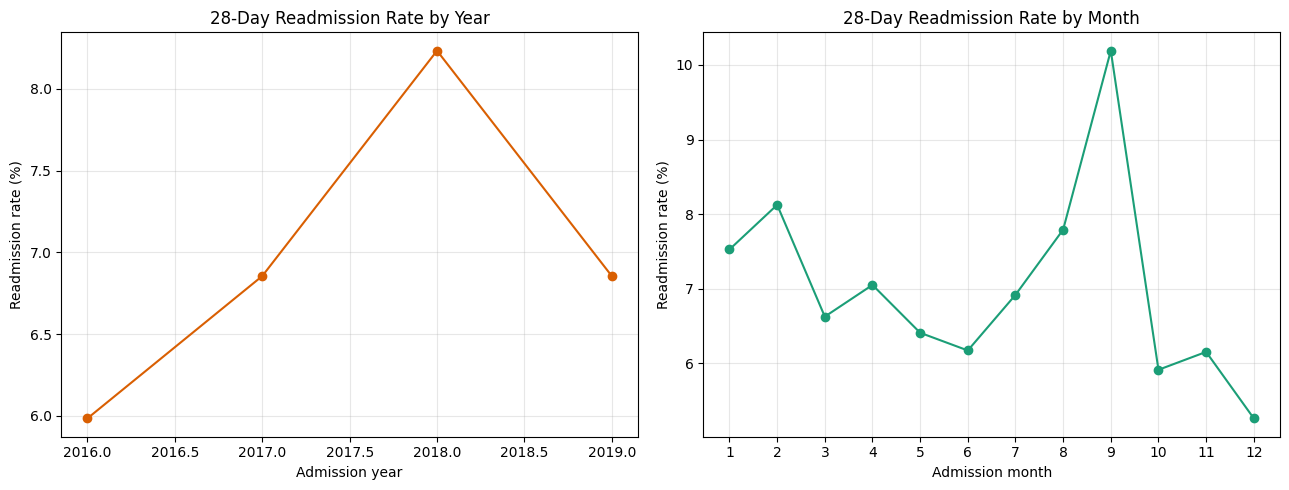

In [39]:

dfrd = hf_df[["admission_date", "readmission_28d"]].copy()
dfrd["admission_date"] = pd.to_datetime(dfrd["admission_date"], errors="coerce")
dfrd["readmission_28d"] = pd.to_numeric(dfrd["readmission_28d"], errors="coerce")
dfrd = dfrd.dropna(subset=["admission_date", "readmission_28d"])

# Create year and month fields for time-based comparison.
dfrd["year"] = dfrd["admission_date"].dt.year
dfrd["month"] = dfrd["admission_date"].dt.month

# The mean of a 0/1 readmission field is the readmission rate.
year_rates = dfrd.groupby("year")["readmission_28d"].mean().mul(100)
month_rates = dfrd.groupby("month")["readmission_28d"].mean().mul(100)

print("Readmission rate by year (%):")
print(year_rates.round(1).to_string())
print("\nReadmission rate by month (%):")
print(month_rates.round(1).to_string())

# Charts: periods with higher points may need discharge-practice review.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(year_rates.index, year_rates.values, marker="o", color="#d95f02")
axes[0].set_title("28-Day Readmission Rate by Year")
axes[0].set_xlabel("Admission year")
axes[0].set_ylabel("Readmission rate (%)")
axes[0].grid(alpha=0.3)

axes[1].plot(month_rates.index, month_rates.values, marker="o", color="#1b9e77")
axes[1].set_title("28-Day Readmission Rate by Month")
axes[1].set_xlabel("Admission month")
axes[1].set_ylabel("Readmission rate (%)")
axes[1].set_xticks(range(1, 13))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px; color: green;"><strong><em>Key insight:<br>
Readmission was highest in 2018 (8.2%) and in September (10.2%), so these periods should be reviewed for possible gaps in discharge planning, follow-up access, or seasonal care processes.*
</em></strong></p>
